## House Price Prediction

![image.png](https://images.pexels.com/photos/1029599/pexels-photo-1029599.jpeg)
<sup>Author: Scott Webb, pexels.com</sup>

In [1]:
# Module import

import seaborn as sns
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import make_column_selector
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer, make_column_selector

## Ames Dataset

The Ames Housing Dataset contains information on residential property sales in Ames, Iowa, USA, covering the period from 2006 to 2010. The dataset is publicly available through Kaggle at:

https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview

The data consists of three files: train.csv, test.csv, and data_description.txt. The train.csv file includes the target variable SalePrice, while the test.csv file contains the same feature set without the target variable. The data_description.txt file provides detailed explanations of all variables and is included at the end of this notebook to help readers understand the dataset.

Train_ds:

In [2]:
# importing the dataset
Filename="train.csv"
Datadir="../prices/Datasets/"
train_ds=pd.read_csv(Datadir + Filename, header=0, index_col="Id")
train_ds.head()


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Test_ds:

In [3]:
Filename = "test.csv"
Datadir="../prices/Datasets/"
# Read with Id as index to match train_df (train uses index_col="Id")
test_ds = pd.read_csv(Datadir + Filename, header=0, index_col="Id")
test_ds.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,113431.348154
1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,156069.039245
1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,180724.011907
1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195835.483736
1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,198040.287389


## Information about Dataset
Train_ds:

In [4]:
train_ds.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

Test_ds:

In [5]:
test_ds.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1459 entries, 1461 to 2919
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1459 non-null   int64  
 1   MSZoning       1455 non-null   object 
 2   LotFrontage    1232 non-null   float64
 3   LotArea        1459 non-null   int64  
 4   Street         1459 non-null   object 
 5   Alley          107 non-null    object 
 6   LotShape       1459 non-null   object 
 7   LandContour    1459 non-null   object 
 8   Utilities      1457 non-null   object 
 9   LotConfig      1459 non-null   object 
 10  LandSlope      1459 non-null   object 
 11  Neighborhood   1459 non-null   object 
 12  Condition1     1459 non-null   object 
 13  Condition2     1459 non-null   object 
 14  BldgType       1459 non-null   object 
 15  HouseStyle     1459 non-null   object 
 16  OverallQual    1459 non-null   int64  
 17  OverallCond    1459 non-null   int64  
 18  YearB

Train_ds contains 1460 rows (instances) and 80 columns (variables), including the target row 'SalePrice', while test_ds contains 1459 rows (instances) and 79 columns (not the target column 'SalePrice'). Both datasets cover the same period of the years 2006-2010. 

In [6]:
train_sold_counts=train_ds['YrSold'].value_counts()
test_sold_counts=test_ds['YrSold'].value_counts()
display("Train_ds Sold Houses", train_sold_counts)
display("Test_ds Sold Houses", test_sold_counts)

'Train_ds Sold Houses'

2009    338
2007    329
2006    314
2008    304
2010    175
Name: YrSold, dtype: int64

'Test_ds Sold Houses'

2007    363
2008    318
2009    309
2006    305
2010    164
Name: YrSold, dtype: int64

## Data Cleaning
I created a copy of train_ds called eda_ds that will be cleaned and used in exploratory data analysis.

In [9]:
eda_ds = pd.concat([train_ds, test_ds], axis=0)

Checking datatypes in eda_ds:

In [10]:
int_vars = eda_ds.select_dtypes(include=[int]).columns.tolist()
float_vars = eda_ds.select_dtypes(include=[float]).columns.tolist()
cat_vars = eda_ds.select_dtypes(include=[object]).columns.tolist()

print("Integer Variables:", int_vars)
print("Float Variables:", float_vars)
print("Categorical Variables:", cat_vars)

Integer Variables: ['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
Float Variables: ['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'SalePrice']
Categorical Variables: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functiona

Some variables were not in the proper data types, for example, the categorical values in numerical data types. For simplicity, I changed float variables to integer variables. I found and imputed missing values.

Missing values:

In [11]:
missing_eda = eda_ds.isnull().sum().sort_values(ascending=False)
missing_eda[missing_eda > 0]

PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
FireplaceQu     1420
LotFrontage      486
GarageCond       159
GarageQual       159
GarageYrBlt      159
GarageFinish     159
GarageType       157
BsmtCond          82
BsmtExposure      82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrType        24
MasVnrArea        23
MSZoning           4
BsmtHalfBath       2
Functional         2
BsmtFullBath       2
Utilities          2
BsmtUnfSF          1
KitchenQual        1
BsmtFinSF1         1
SaleType           1
GarageCars         1
GarageArea         1
TotalBsmtSF        1
Exterior2nd        1
Exterior1st        1
Electrical         1
BsmtFinSF2         1
dtype: int64

In [12]:
# Fill fields
num_fill = [
    'MasVnrArea', 'GarageYrBlt', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
    'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea',
    'YearBuilt', 'YearRemodAdd', 'LotFrontage'
]
zero_imputer = SimpleImputer(strategy="median", fill_value=0)
eda_ds[num_fill] = zero_imputer.fit_transform(eda_ds[num_fill])

# ---------- 2) Categorical imputations ----------
cat_fill = ['MSZoning', 'Utilities', 'Functional', 'Exterior1st', 'Exterior2nd',
             'SaleType', 'KitchenQual', 'Electrical','PoolQC', 'MiscFeature', 
             'Alley', 'Fence', 'FireplaceQu', 'GarageFinish', 'GarageQual',
             'GarageType', 'GarageCond', 'BsmtExposure', 'BsmtCond',
             'BsmtQual', 'BsmtFinType2', 'BsmtFinType1' ]

# only columns that exist
cat_fill = [c for c in cat_fill if c in eda_ds.columns]

mode_imputer = SimpleImputer(strategy="most_frequent")
eda_ds[cat_fill] = mode_imputer.fit_transform(eda_ds[cat_fill])

# ---------- 3) Dtype conversions ----------
int_to_strings = ['MSSubClass', 'OverallQual', 'OverallCond', 'MoSold', 'BsmtFullBath',
                  'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
                  'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'MasVnrType']

float_to_int = ['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
                'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath',
                'GarageCars', 'GarageArea', 'GarageYrBlt', 'YrSold', 'YearBuilt', 'YearRemodAdd']

# only convert columns that exist (safer)
float_to_int = [c for c in float_to_int if c in eda_ds.columns]
int_to_strings = [c for c in int_to_strings if c in eda_ds.columns]

eda_ds[float_to_int] = eda_ds[float_to_int].round().astype("int64")
eda_ds[int_to_strings] = eda_ds[int_to_strings].astype(str)


Final check:

In [13]:
eda_ds.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2919 entries, 1 to 2919
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   object 
 1   MSZoning       2919 non-null   object 
 2   LotFrontage    2919 non-null   int64  
 3   LotArea        2919 non-null   int64  
 4   Street         2919 non-null   object 
 5   Alley          2919 non-null   object 
 6   LotShape       2919 non-null   object 
 7   LandContour    2919 non-null   object 
 8   Utilities      2919 non-null   object 
 9   LotConfig      2919 non-null   object 
 10  LandSlope      2919 non-null   object 
 11  Neighborhood   2919 non-null   object 
 12  Condition1     2919 non-null   object 
 13  Condition2     2919 non-null   object 
 14  BldgType       2919 non-null   object 
 15  HouseStyle     2919 non-null   object 
 16  OverallQual    2919 non-null   object 
 17  OverallCond    2919 non-null   object 
 18  YearBuil

In [15]:
# creating train dataset for eda
n_train = train_ds.shape[0]

eda_train_ds = eda_ds.iloc[:n_train].copy()


## EDA
Exploratory Data Analysis (EDA) is conducted to gain insight into the distributions and characteristics of the dataset prior to modeling. Visualization techniques play a key role in identifying skewness, sparsity, outliers, and potential data quality issues.

For this purpose, histograms are used to analyze numerical variables, and bar plots are used to examine categorical variables.

The following histograms summarize the distributions of the numerical features and highlight key patterns relevant for feature engineering and model selection.

### Histograms

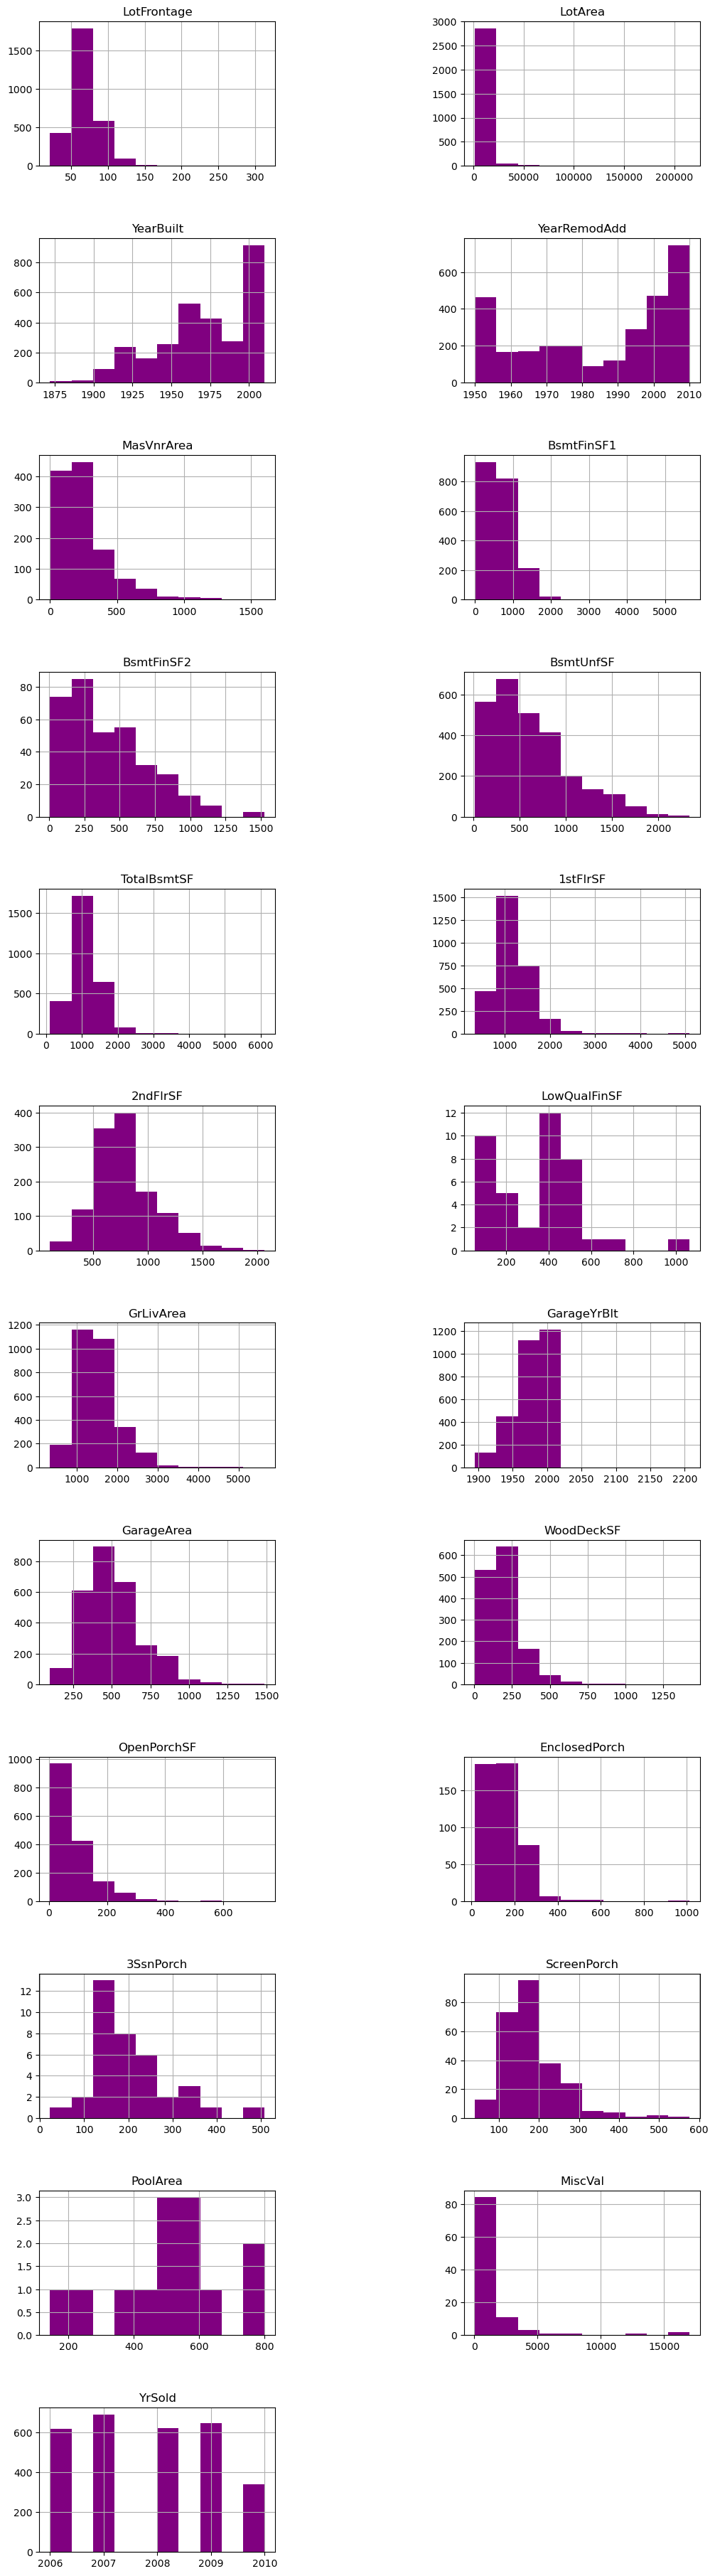

In [16]:
numerical = eda_ds.select_dtypes("int64")

numerical.apply(lambda col: col[col != 0]).hist(
    bins=10, figsize=(12, 70), color="purple", layout=(18, 2)
    )

plt.subplots_adjust(hspace=0.5, wspace=0.8)
plt.show()


Summary:

In [17]:
pd.set_option("display.max_columns", None)
numerical.describe(include=['int64'])


,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,GarageYrBlt,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000
mean,69.088386,10168.114080,1971.312778,1984.264474,101.396026,441.398082,49.565262,560.739979,1051.756423,1159.581706,336.483727,4.694416,1500.759849,1978.161699,472.877013,93.709832,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,2007.792737
std,21.317898,7886.996359,30.291442,20.894344,178.854579,455.534777,169.179104,439.471764,440.692210,392.362079,428.701456,46.396825,506.051045,24.868576,215.357944,126.526589,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,1.314964
min,21.000000,1300.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2006.000000
25%,60.000000,7478.000000,1953.500000,1965.000000,0.000000,0.000000,0.000000,220.000000,793.000000,876.000000,0.000000,0.000000,1126.000000,1961.500000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2007.000000
50%,68.000000,9453.000000,1973.000000,1993.000000,0.000000,368.000000,0.000000,467.000000,990.000000,1082.000000,0.000000,0.000000,1444.000000,1979.000000,480.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2008.000000
75%,78.000000,11570.000000,2001.000000,2004.000000,163.500000,733.000000,0.000000,805.000000,1302.000000,1387.500000,704.000000,0.000000,1743.500000,2001.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2009.000000
max,313.000000,215245.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,2207.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,2010.000000


The dataset contains houses constructed between 1872 and 2010, with a significant proportion built after 2000. Most remodeling activities were concentrated around 2004. The median house age at the time of sale is approximately 35 years.\
Sale prices range from $34,900 to $755,000, with a median price of $163,000, indicating substantial variability and the presence of high-end properties.\
The median above-ground living area (GrLivArea) is 1,464 square feet, though the distribution exhibits strong variability with several large outliers. Many houses lack certain basement features, resulting in zero-inflated distributions for some basement-related variables. Outdoor and luxury amenities such as PoolArea, 3SsnPorch, EnclosedPorch, and MiscVal are relatively sparse, as they are present only in a small subset of properties.

### Barplots

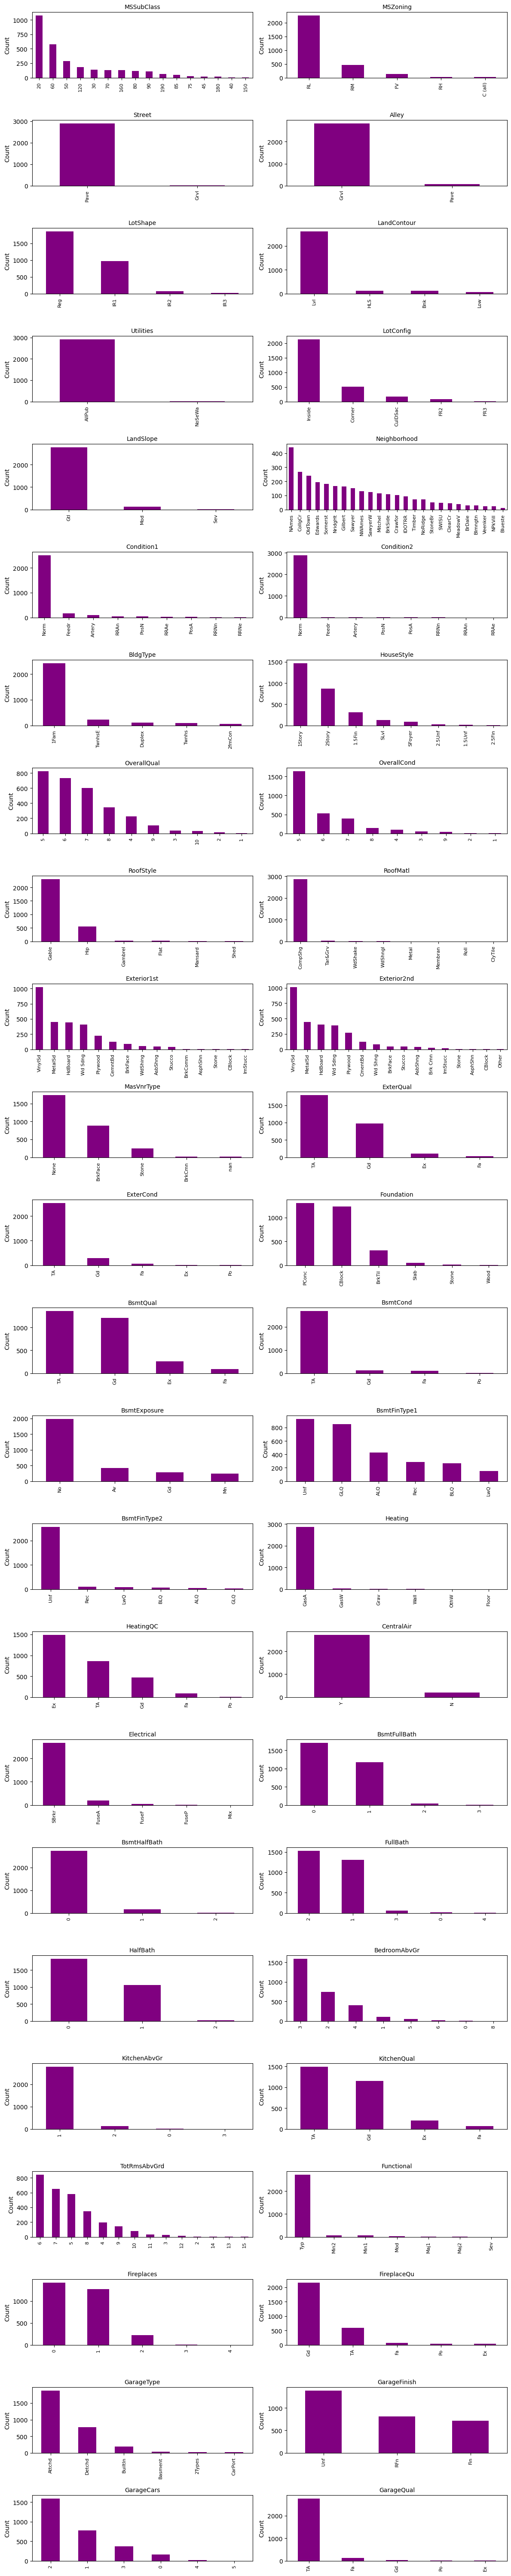

In [19]:
categorical = eda_ds.select_dtypes("object")

n_cols = 2
n_rows = 24

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 60))
axes = axes.flatten()

for ax, col in zip(axes, categorical.columns):
    vc = categorical[col].value_counts(dropna=False)

    vc.plot(kind='bar',  ax=ax, color='purple')
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', rotation=90, labelsize=8)
    ax.set_ylabel('Count')

# Hide any unused axes
for ax in axes[len(categorical.columns):]:
    ax.axis('off')
plt.subplots_adjust(hspace=0.8, wspace=0.8)
plt.tight_layout()
plt.show()


In [20]:
categorical.describe()

,MSSubClass,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageFinish,GarageCars,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,MoSold,SaleType,SaleCondition
count,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919
unique,16,5,2,2,4,4,2,5,3,25,9,8,5,8,10,9,6,8,15,16,5,4,5,6,4,4,4,6,6,6,5,2,5,4,3,5,3,8,4,4,14,7,5,5,6,3,6,5,5,3,3,4,4,12,9,6
top,20,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,5,Gable,CompShg,VinylSd,VinylSd,None,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,0,0,2,0,3,1,TA,6,Typ,0,Gd,Attchd,Unf,2,TA,TA,Y,Ex,MnPrv,Shed,6,WD,Normal
freq,1079,2269,2907,2841,1859,2622,2918,2133,2778,443,2511,2889,2425,1471,825,1645,2310,2876,1026,1015,1742,1798,2538,1308,1364,2688,1986,930,2573,2874,1493,2723,2672,1707,2744,1530,1834,1596,2785,1493,844,2719,1420,2164,1880,1389,1595,2763,2813,2641,2913,2677,2909,503,2526,2402


A typical house in the dataset is located in a Residential Low Density (RL) zone and is a single-family (1Fam) property. Most homes are one-story structures with a gable roof and a poured concrete foundation. Heating is typically provided by a gas forced warm air furnace (GasA), and the majority of houses are equipped with central air conditioning. Nearly all properties have paved road access, are connected to public utilities and sewage systems (AllPub), and are situated on flat or gently sloped terrain.

### Average Sale Price and Total Amount of Sales for Every Year

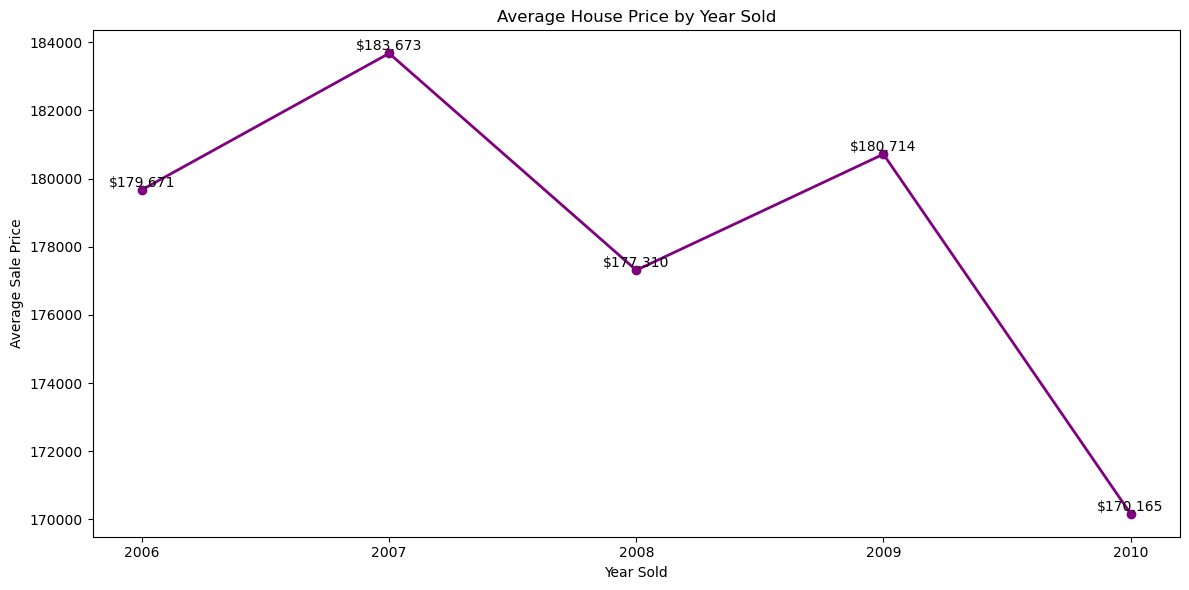

In [22]:
avg_price_by_year = eda_ds.groupby('YrSold')['SalePrice'].mean()

plt.figure(figsize=(12, 6))
ax = avg_price_by_year.plot(kind='line', marker='o', linewidth=2, color='purple')

plt.title('Average House Price by Year Sold')
plt.xlabel('Year Sold')
plt.ylabel('Average Sale Price')
plt.xticks(avg_price_by_year.index)  # Set x-ticks to be the years

for year, price in avg_price_by_year.items():
    ax.text(year, price, f'${price:,.0f}', ha='center', va='bottom')
plt.subplots_adjust(hspace=0.8, wspace=0.8)
plt.tight_layout()
plt.show()


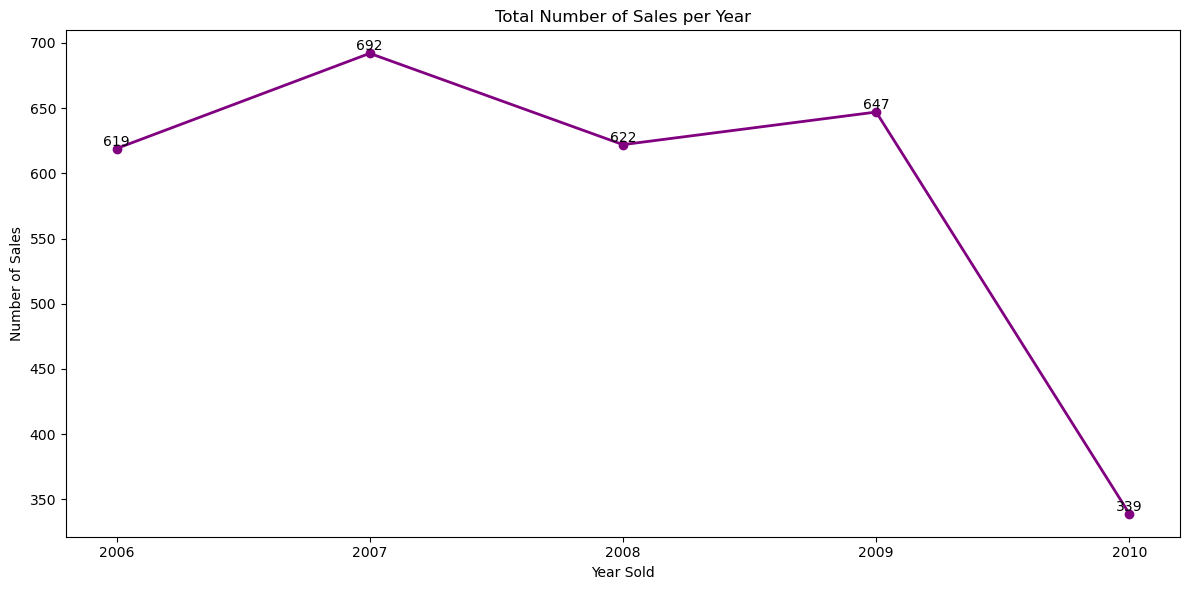

In [23]:
sales_per_year = eda_ds.groupby('YrSold').size()

plt.figure(figsize=(12, 6))
ax = sales_per_year.plot(kind='line', marker='o', linewidth=2, color='purple')

plt.title('Total Number of Sales per Year')
plt.xlabel('Year Sold')
plt.ylabel('Number of Sales')
plt.xticks(sales_per_year.index)  # Set x-ticks to be the years

for year, count in sales_per_year.items():
    ax.text(year, count, f'{count}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Average prices increased from 2006 to a peak in 2007, followed by a sharp decline in 2008. A partial recovery is observed in 2009, with prices decreasing again in 2010.\

The total number of sales increases from 2006 to 2007, declines in 2008, and then reaches its highest level in 2009. A substantial drop in the number of sales is observed in 2010.\

This noticeable volatility is timed closely with the global economic crisis of 2008.

### Correlation of Variables with SalePrice

To explore the relationship between numerical features and the target variable SalePrice, scatterplots are used to visualize potential correlations. These plots allow the identification of linear or nonlinear trends between each numerical predictor and the sale price.\
Positive or negative correlations may. be observed as diagonally. increasing or decreasing patterns in the scatter plots, while weak or no correlation is indicated by a more diffuse or random distribution of points.

Scatterplots:

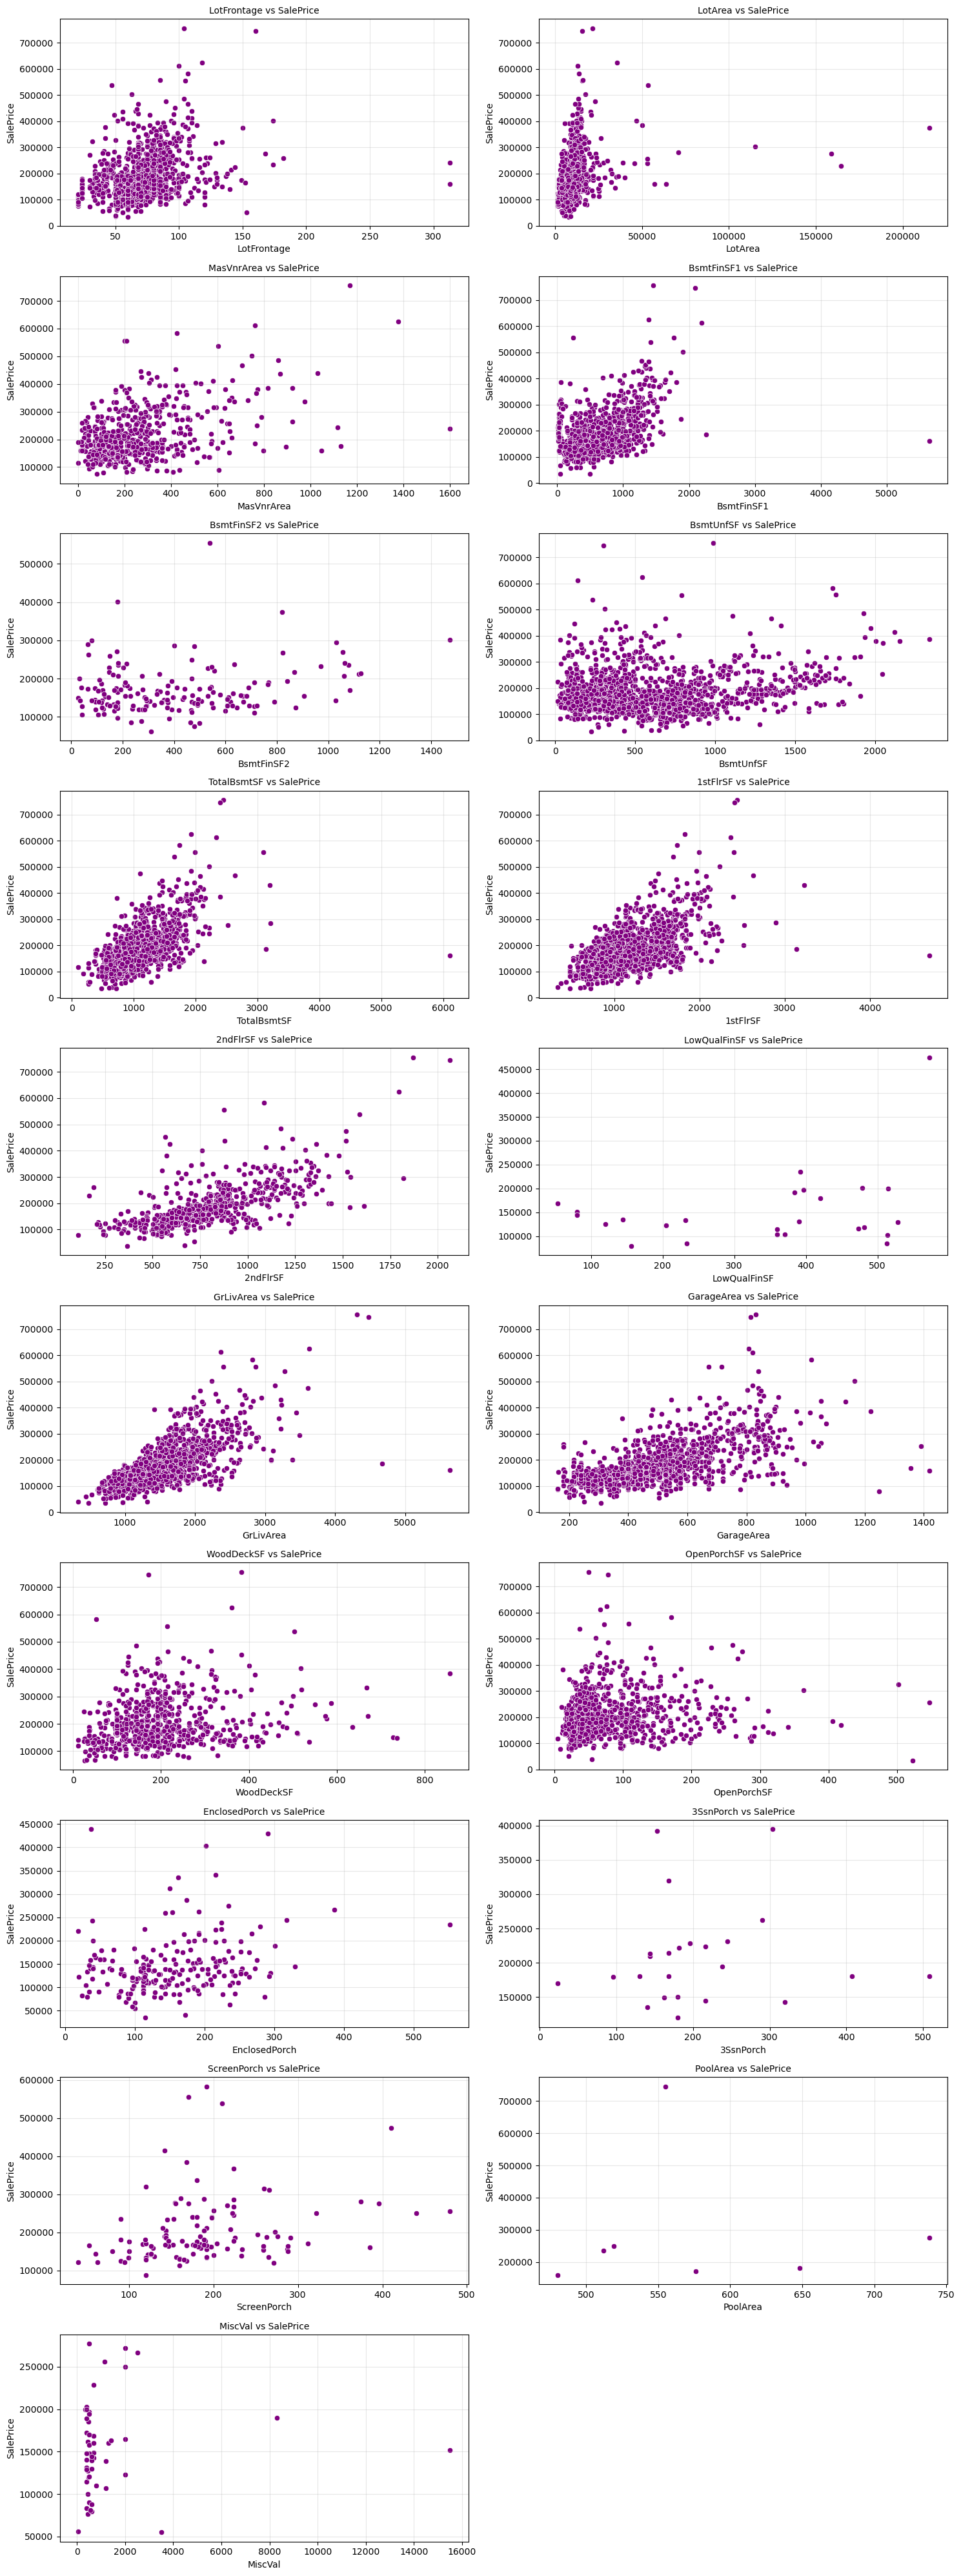

In [26]:
# Create scatterplots for all numerical variables against SalePrice
numerical_cols = eda_train_ds.select_dtypes(include=['int64', 'float']).columns.tolist()

numerical_cols.remove('YearBuilt')  # Remove  some variables
numerical_cols.remove('YearRemodAdd')
numerical_cols.remove('GarageYrBlt')
numerical_cols.remove('YrSold')
numerical_cols.remove('SalePrice')

n_cols = 2
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15,  4* n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numerical_cols):
    subset = eda_train_ds[eda_train_ds[col] > 0]

    sns.scatterplot(
        data=subset,
        x=col,
        y='SalePrice',
        ax=ax,
        color='purple'
    )

    ax.set_title(f'{col} vs SalePrice', fontsize=10)
    ax.grid(alpha=0.3)

# Hide any unused axes
for ax in axes[len(numerical_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Variables 'LotFrontage', 'BSmtFinSF1', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'GarageArea' seem to have considerable correlation.

I am going to use median house prices in correlation with 'year' variables - 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt' to reduce the influence of extreme values and outliers.

Median sales for 'year' variables:

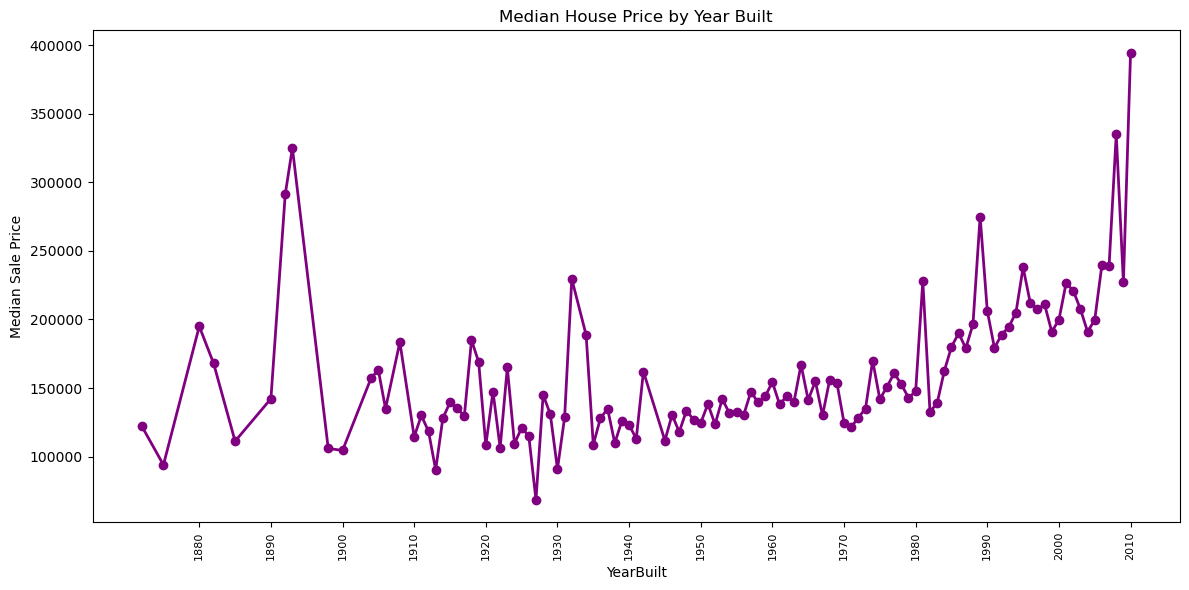

In [27]:
year_built_price = eda_train_ds.groupby('YearBuilt')['SalePrice'].median()
xticks = year_built_price.index[year_built_price.index % 10 == 0]
plt.figure(figsize=(12, 6))
ax = year_built_price.plot(kind='line', marker='o', linewidth=2, color='purple')

plt.title('Median House Price by Year Built')
plt.xlabel('YearBuilt')
plt.ylabel('Median Sale Price')
plt.xticks(xticks, rotation=90, fontsize=8)  # Set x-ticks to be the years
#plt.subplots_adjust(hspace=0.8, wspace=0.8)
plt.tight_layout()
plt.show()


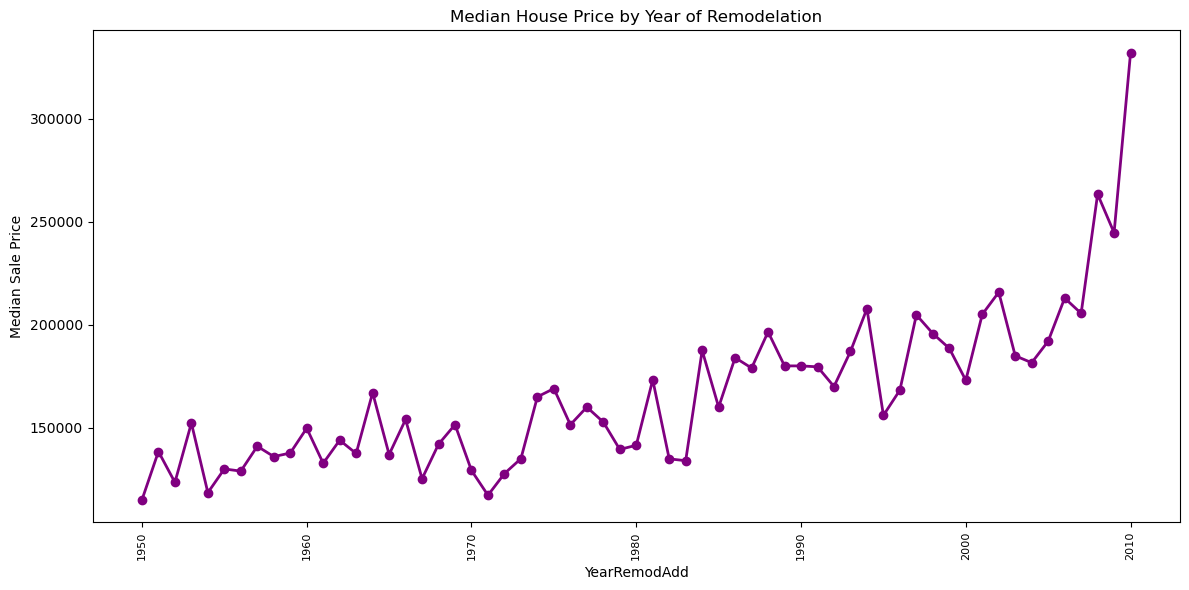

In [29]:
yr_remod_add_price=eda_train_ds.groupby('YearRemodAdd')['SalePrice'].median()
xticks = yr_remod_add_price.index[yr_remod_add_price.index % 10 == 0]
plt.figure(figsize=(12, 6))
ax = yr_remod_add_price.plot(kind='line', marker='o', linewidth=2, color='purple')

plt.title('Median House Price by Year of Remodelation')
plt.xlabel('YearRemodAdd')
plt.ylabel('Median Sale Price')
plt.xticks(xticks, rotation=90, fontsize=8)  # Set x-ticks to be the years
#plt.subplots_adjust(hspace=0.8, wspace=0.8)
plt.tight_layout()
plt.show()


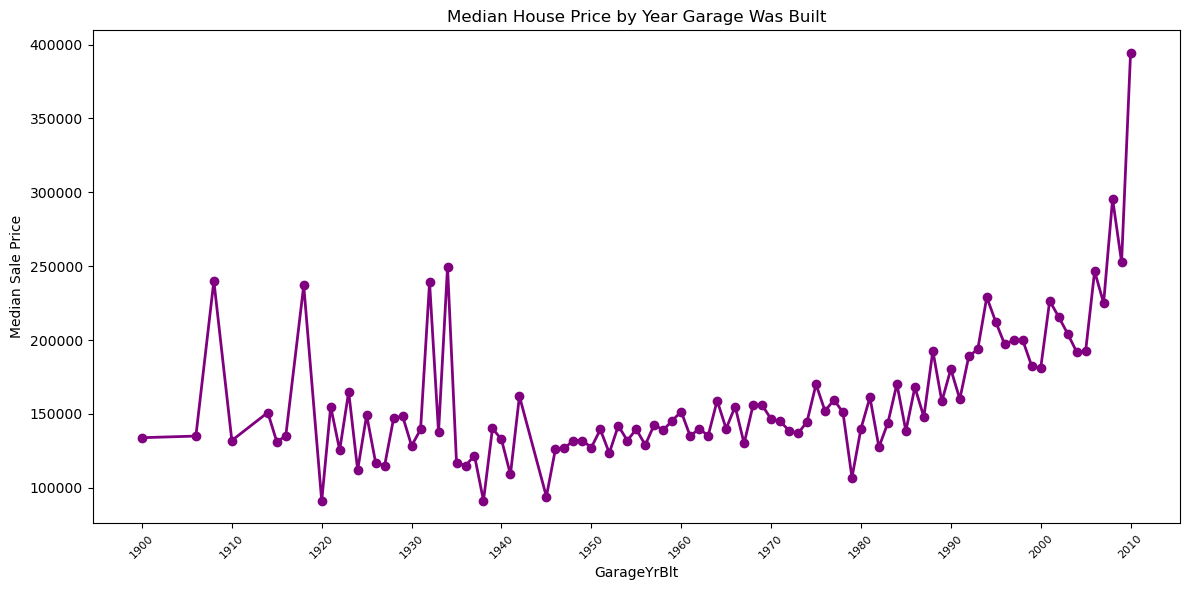

In [30]:
garage_yr_built_price = (
    eda_train_ds
        .dropna(subset=["GarageYrBlt"])
        .query("GarageYrBlt > 0")
        .groupby("GarageYrBlt")["SalePrice"]
        .median()
        .sort_index()
)

# X-ticks every 10 years
xticks = garage_yr_built_price.index[
    garage_yr_built_price.index % 10 == 0
]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(
    garage_yr_built_price.index,
    garage_yr_built_price.values,
    marker="o",
    linewidth=2,
    color="purple"
)

plt.title("Median House Price by Year Garage Was Built")
plt.xlabel("GarageYrBlt")
plt.ylabel("Median Sale Price")
plt.xticks(xticks, rotation=45, fontsize=8)

plt.tight_layout()
plt.show()


All 'year' variables showed a good, positive correlation with SalePrice.

I used box plots to examine the relationship between categorical variables and the target variable 'SalePrice'. Boxplots provide a concise summary of the distribution of sale prices within each category, allowing for comparison of medians, variability, and the presence of outliers across groups.

Boxplots:

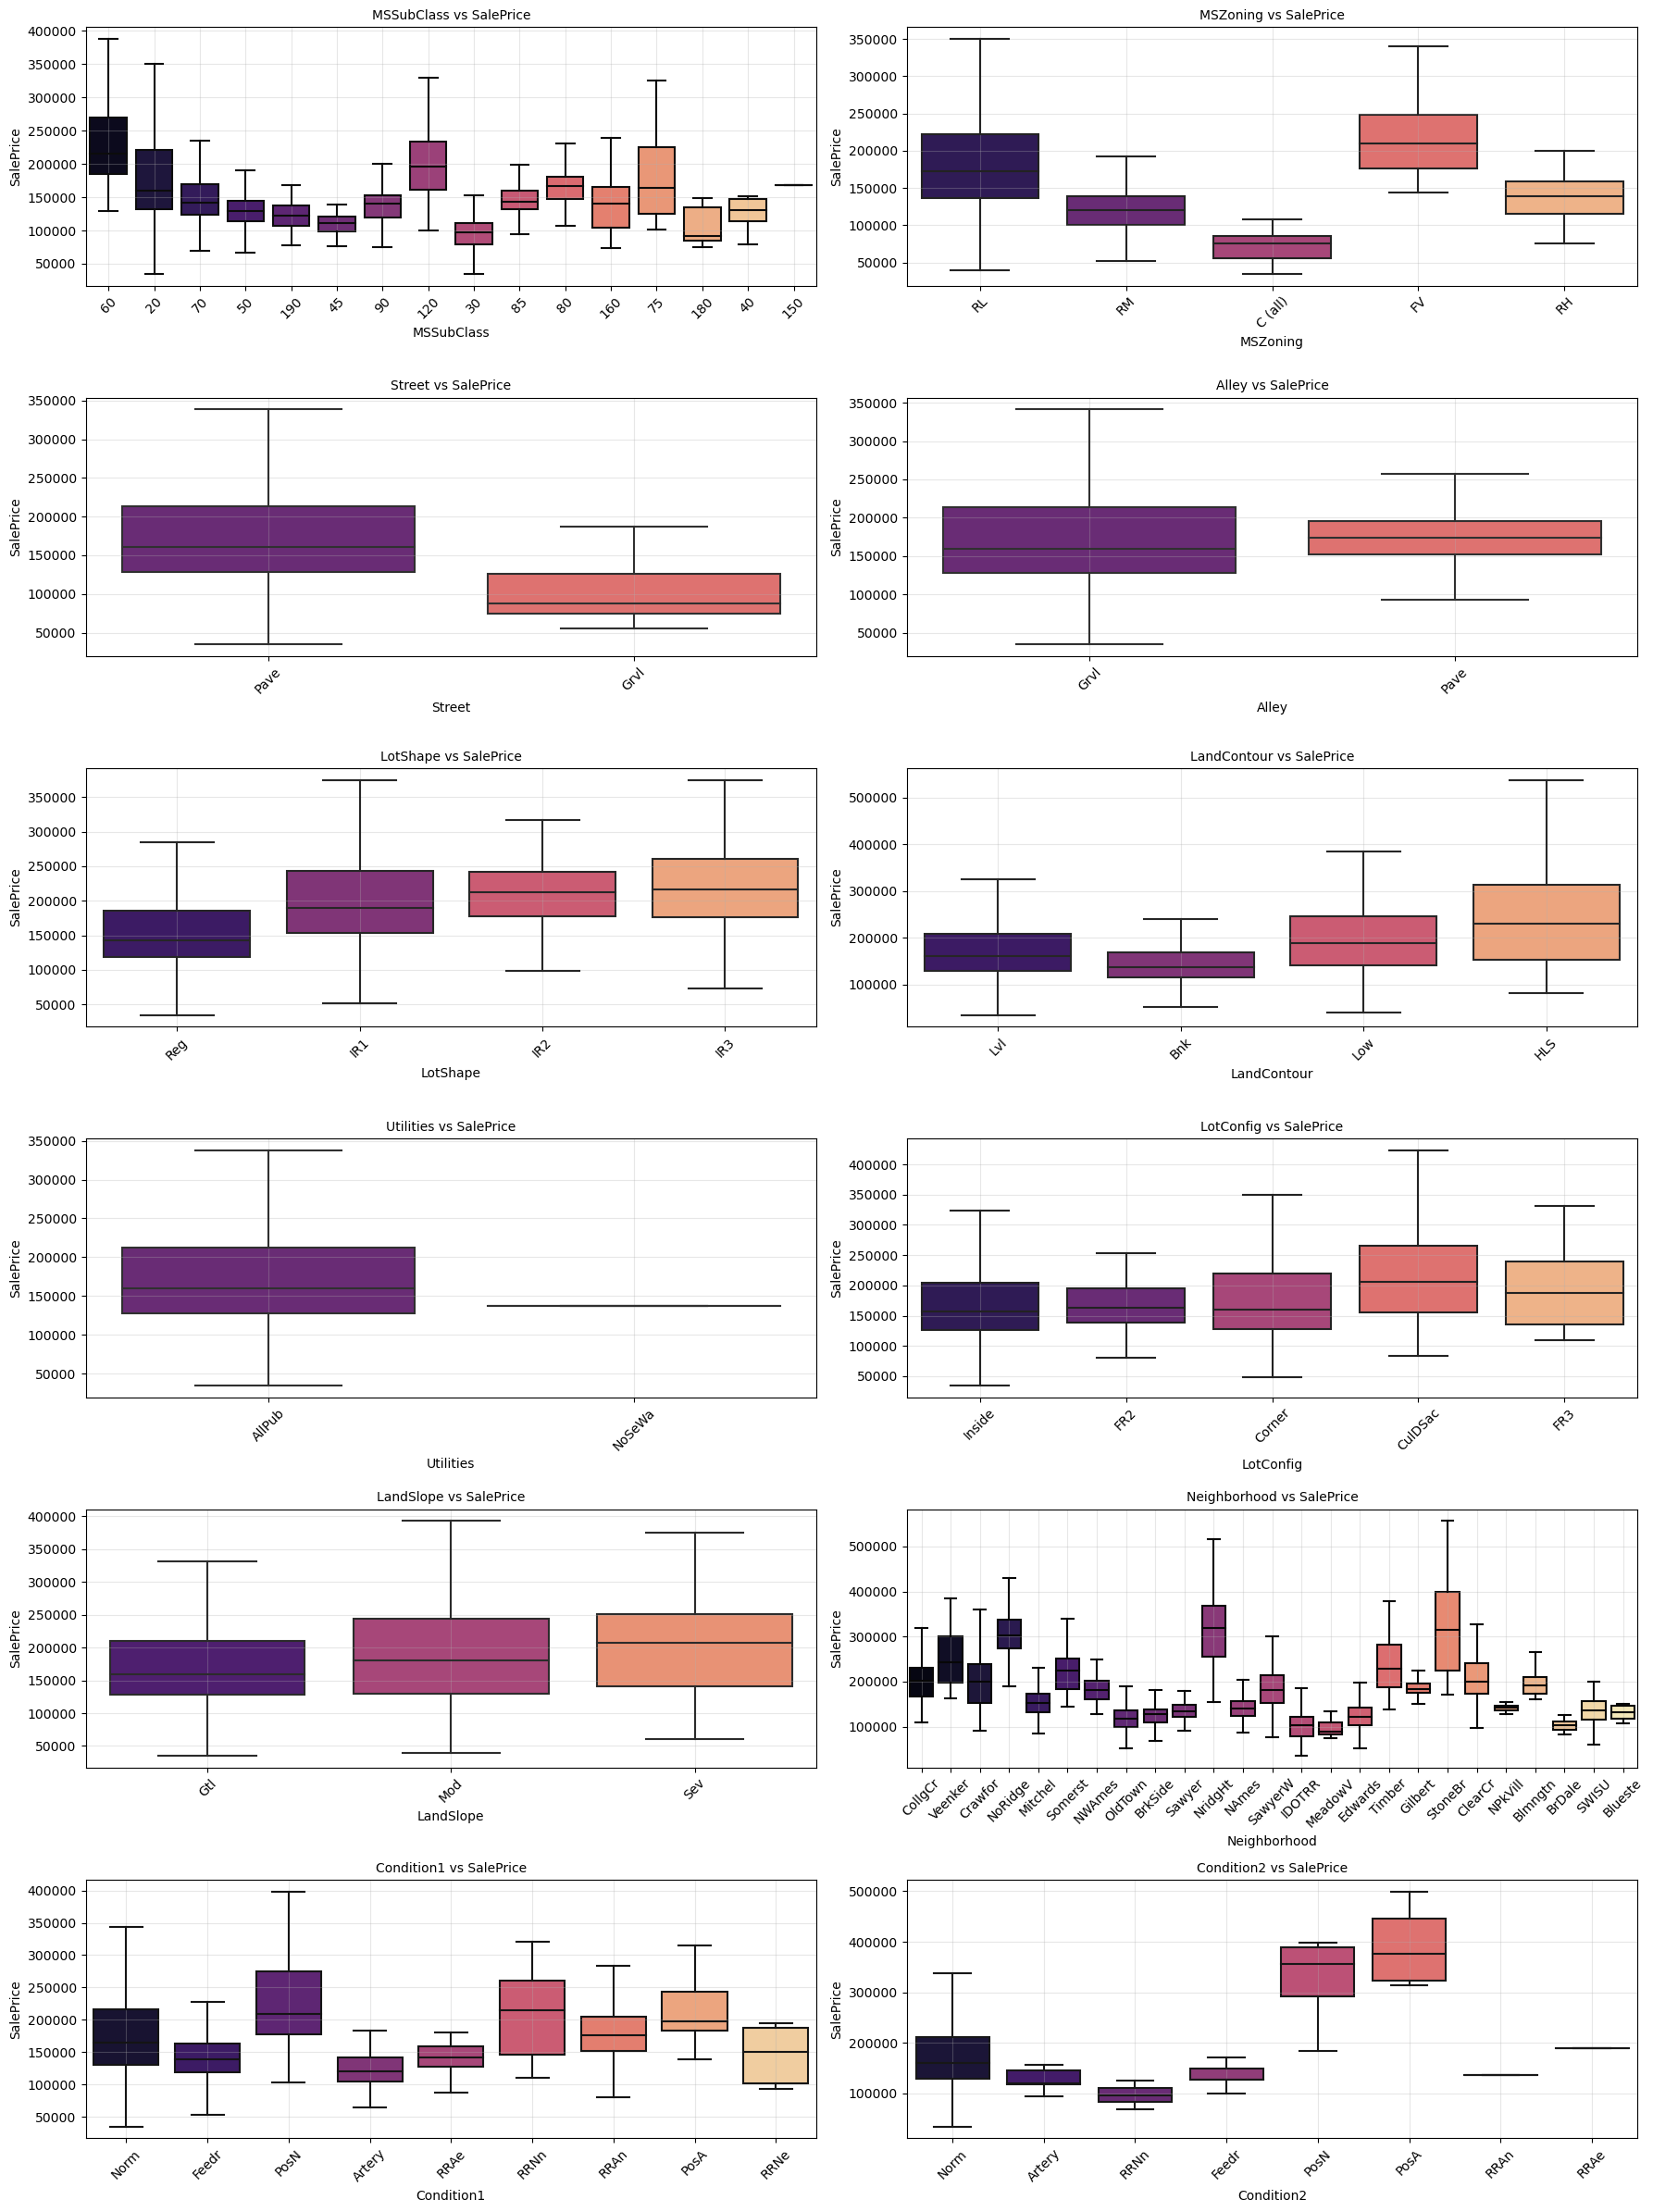

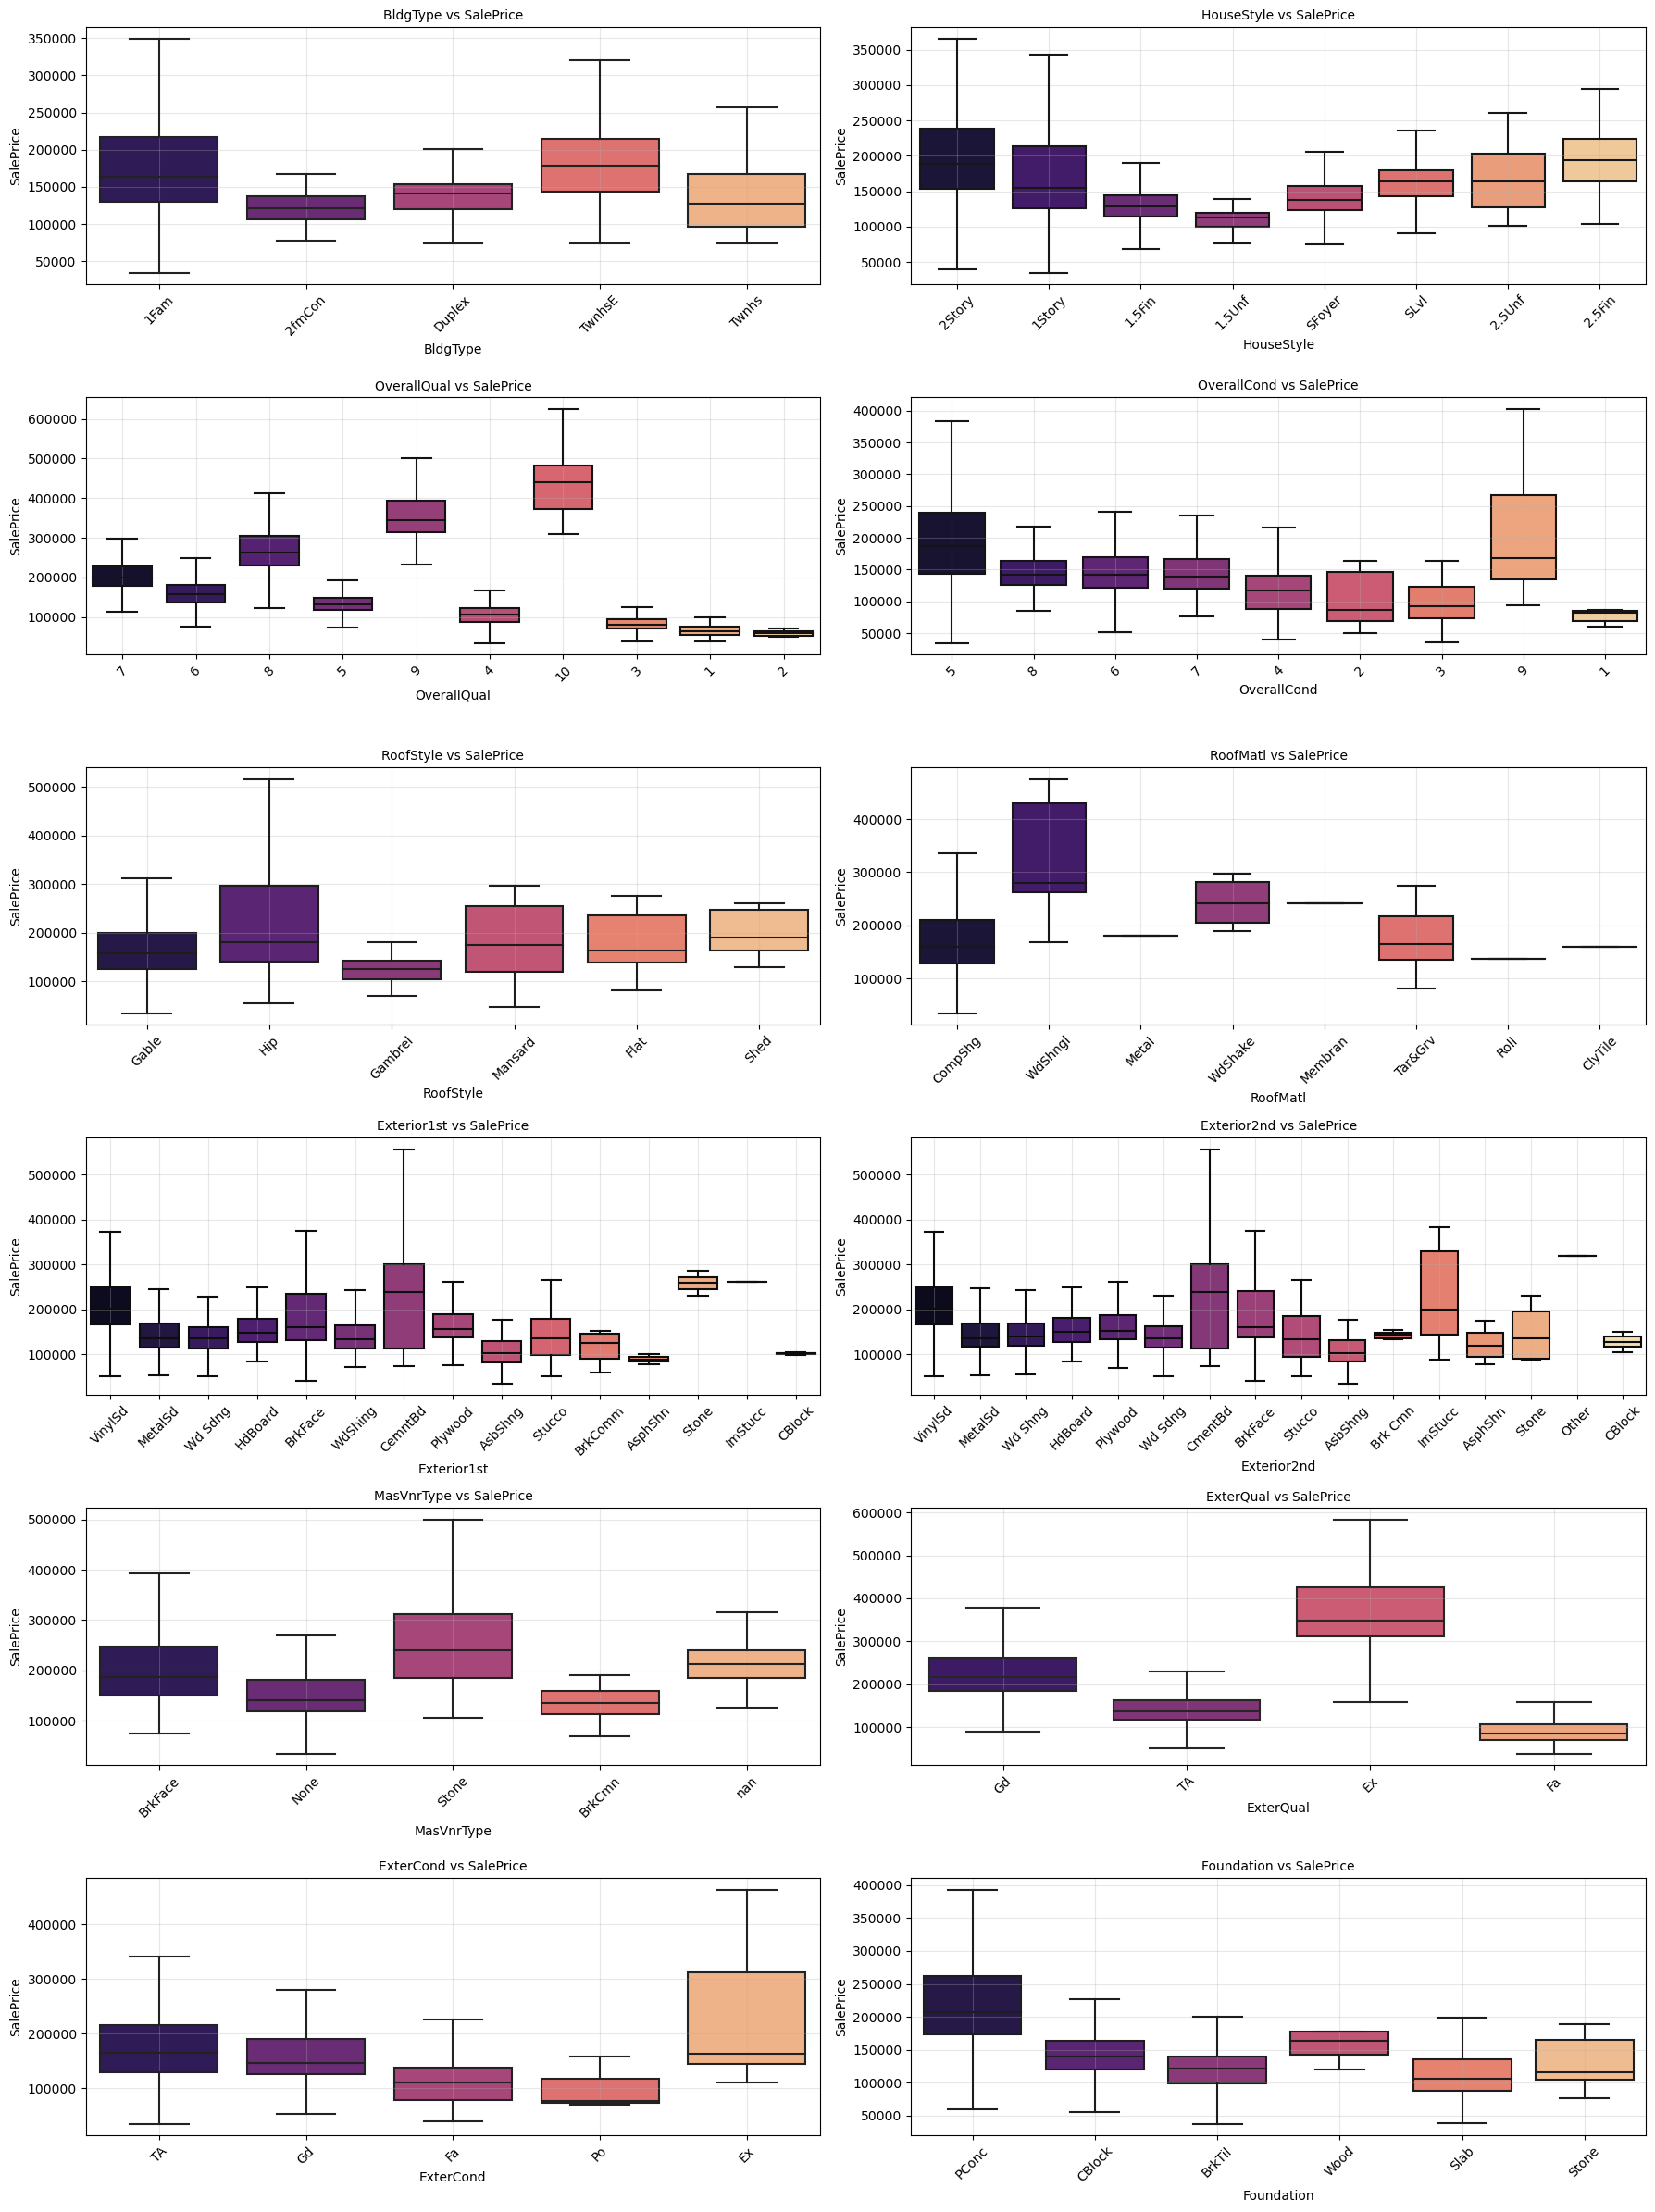

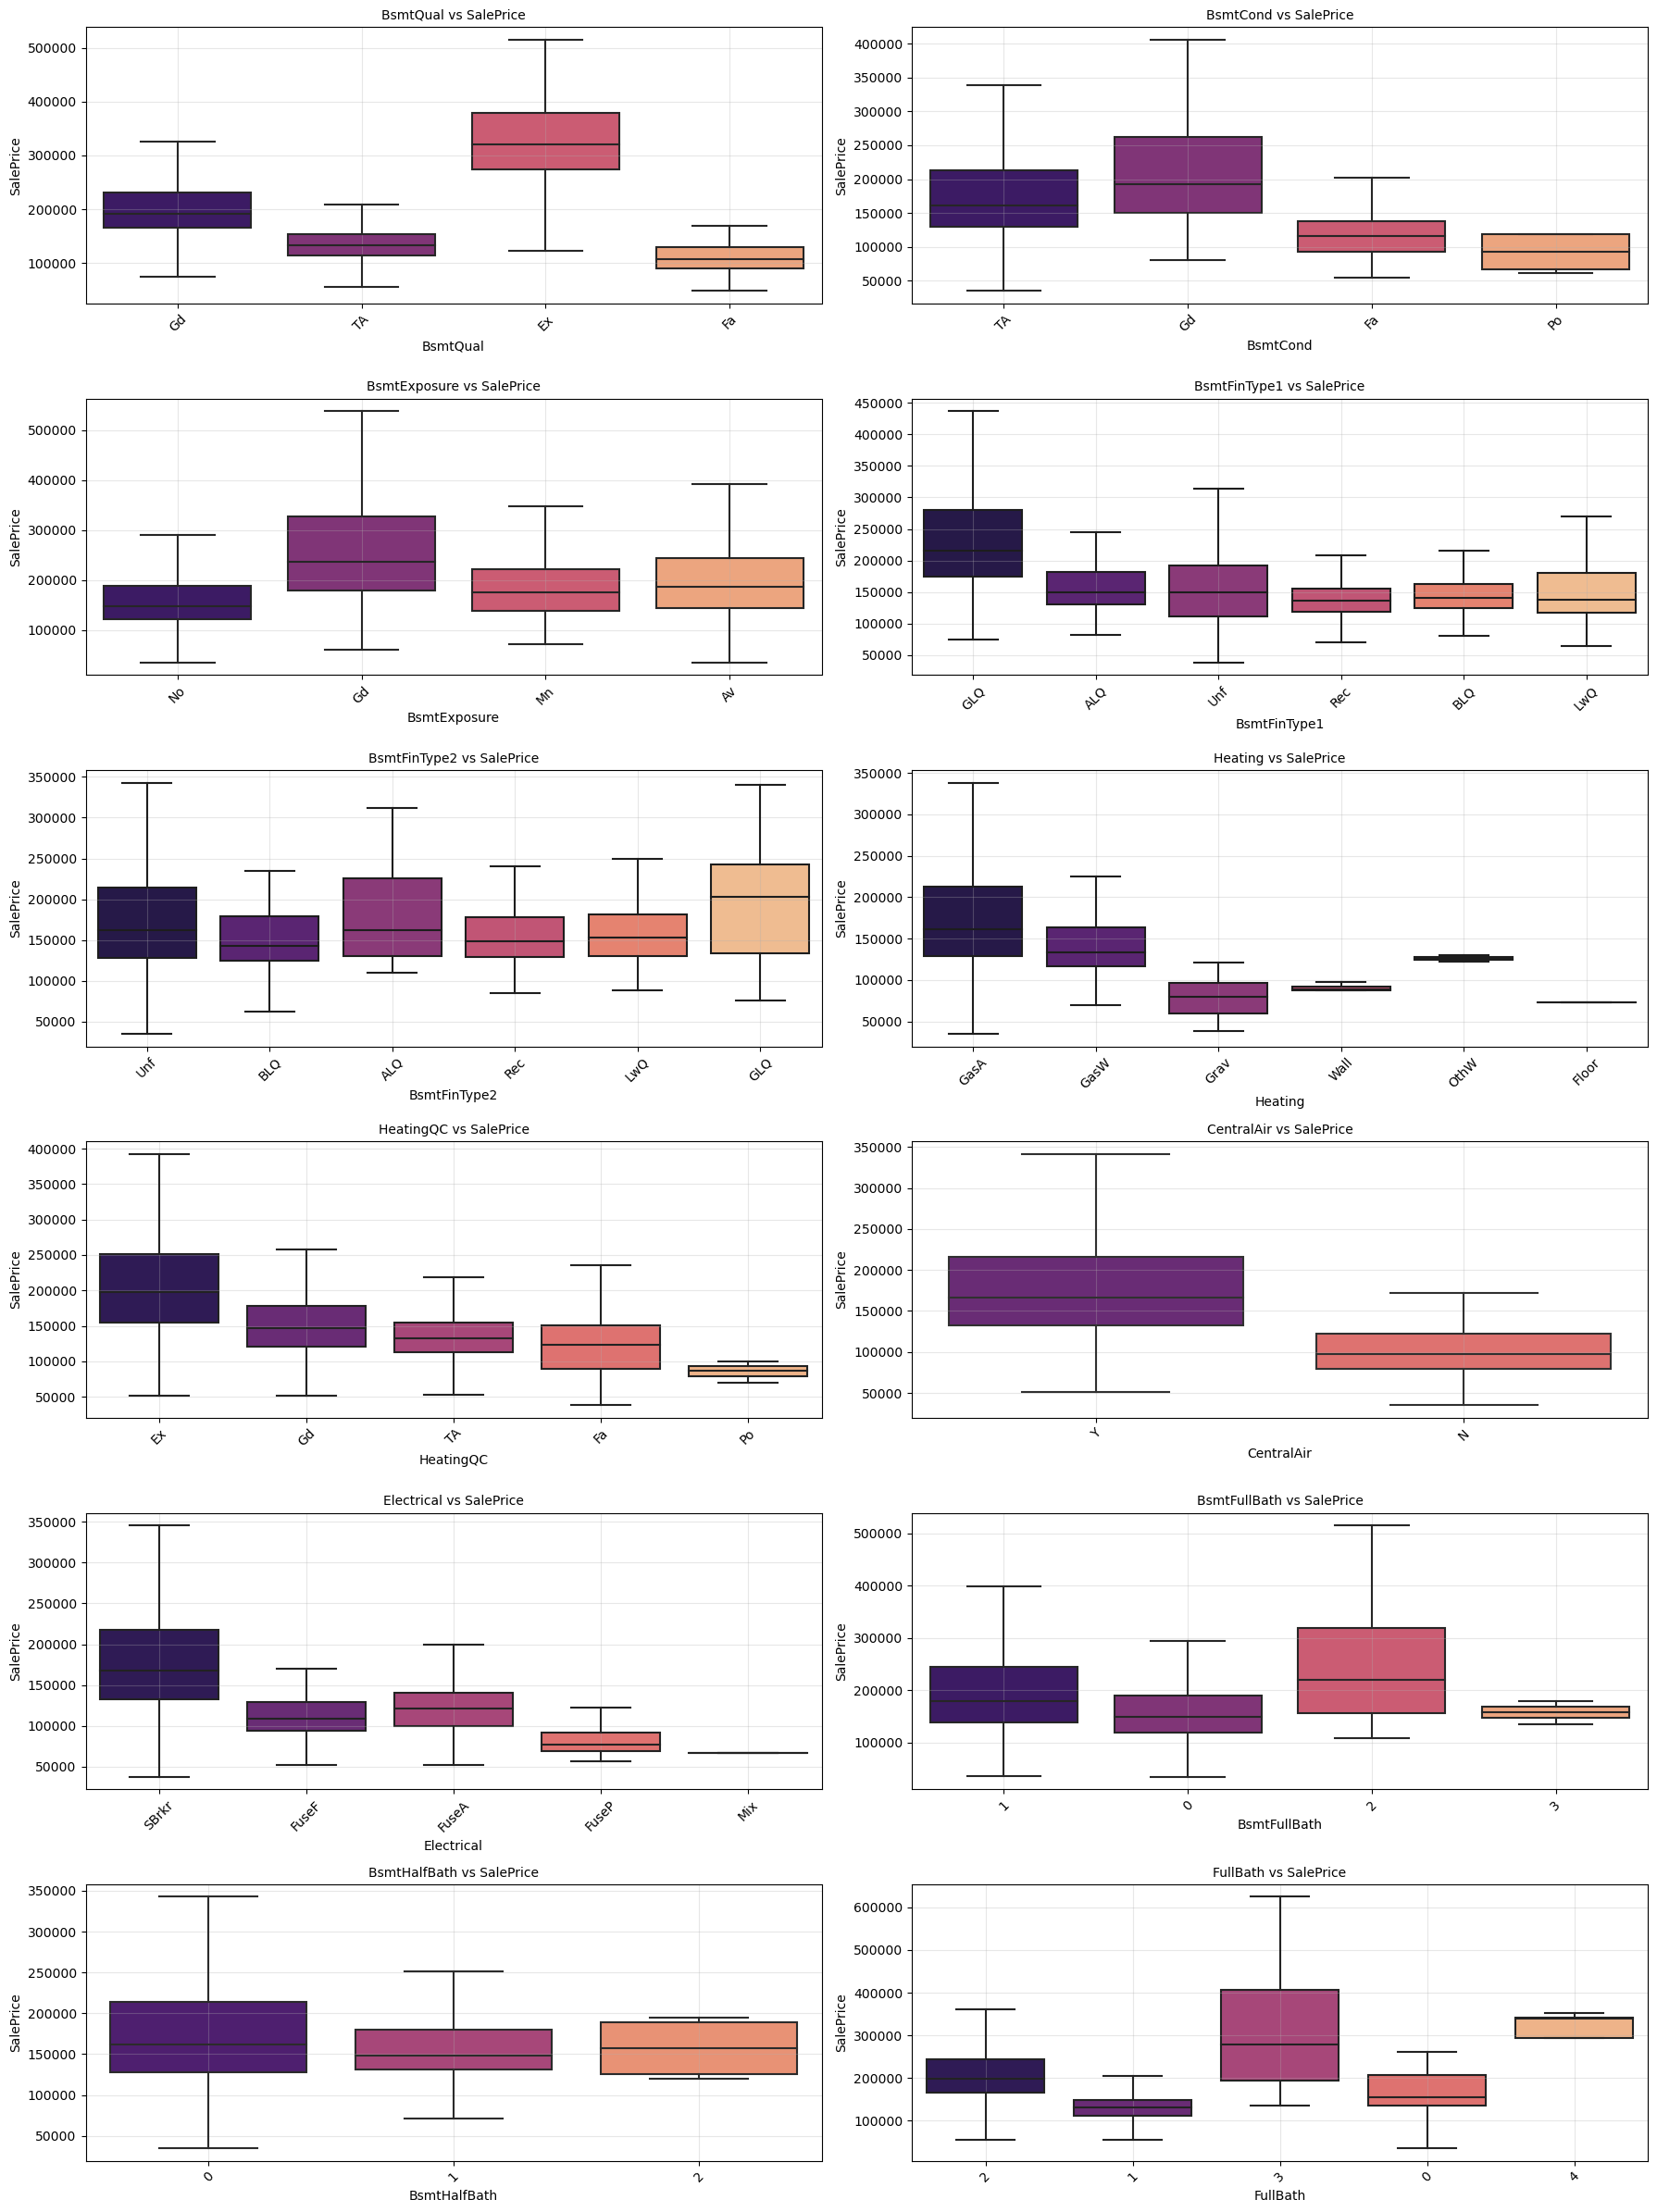

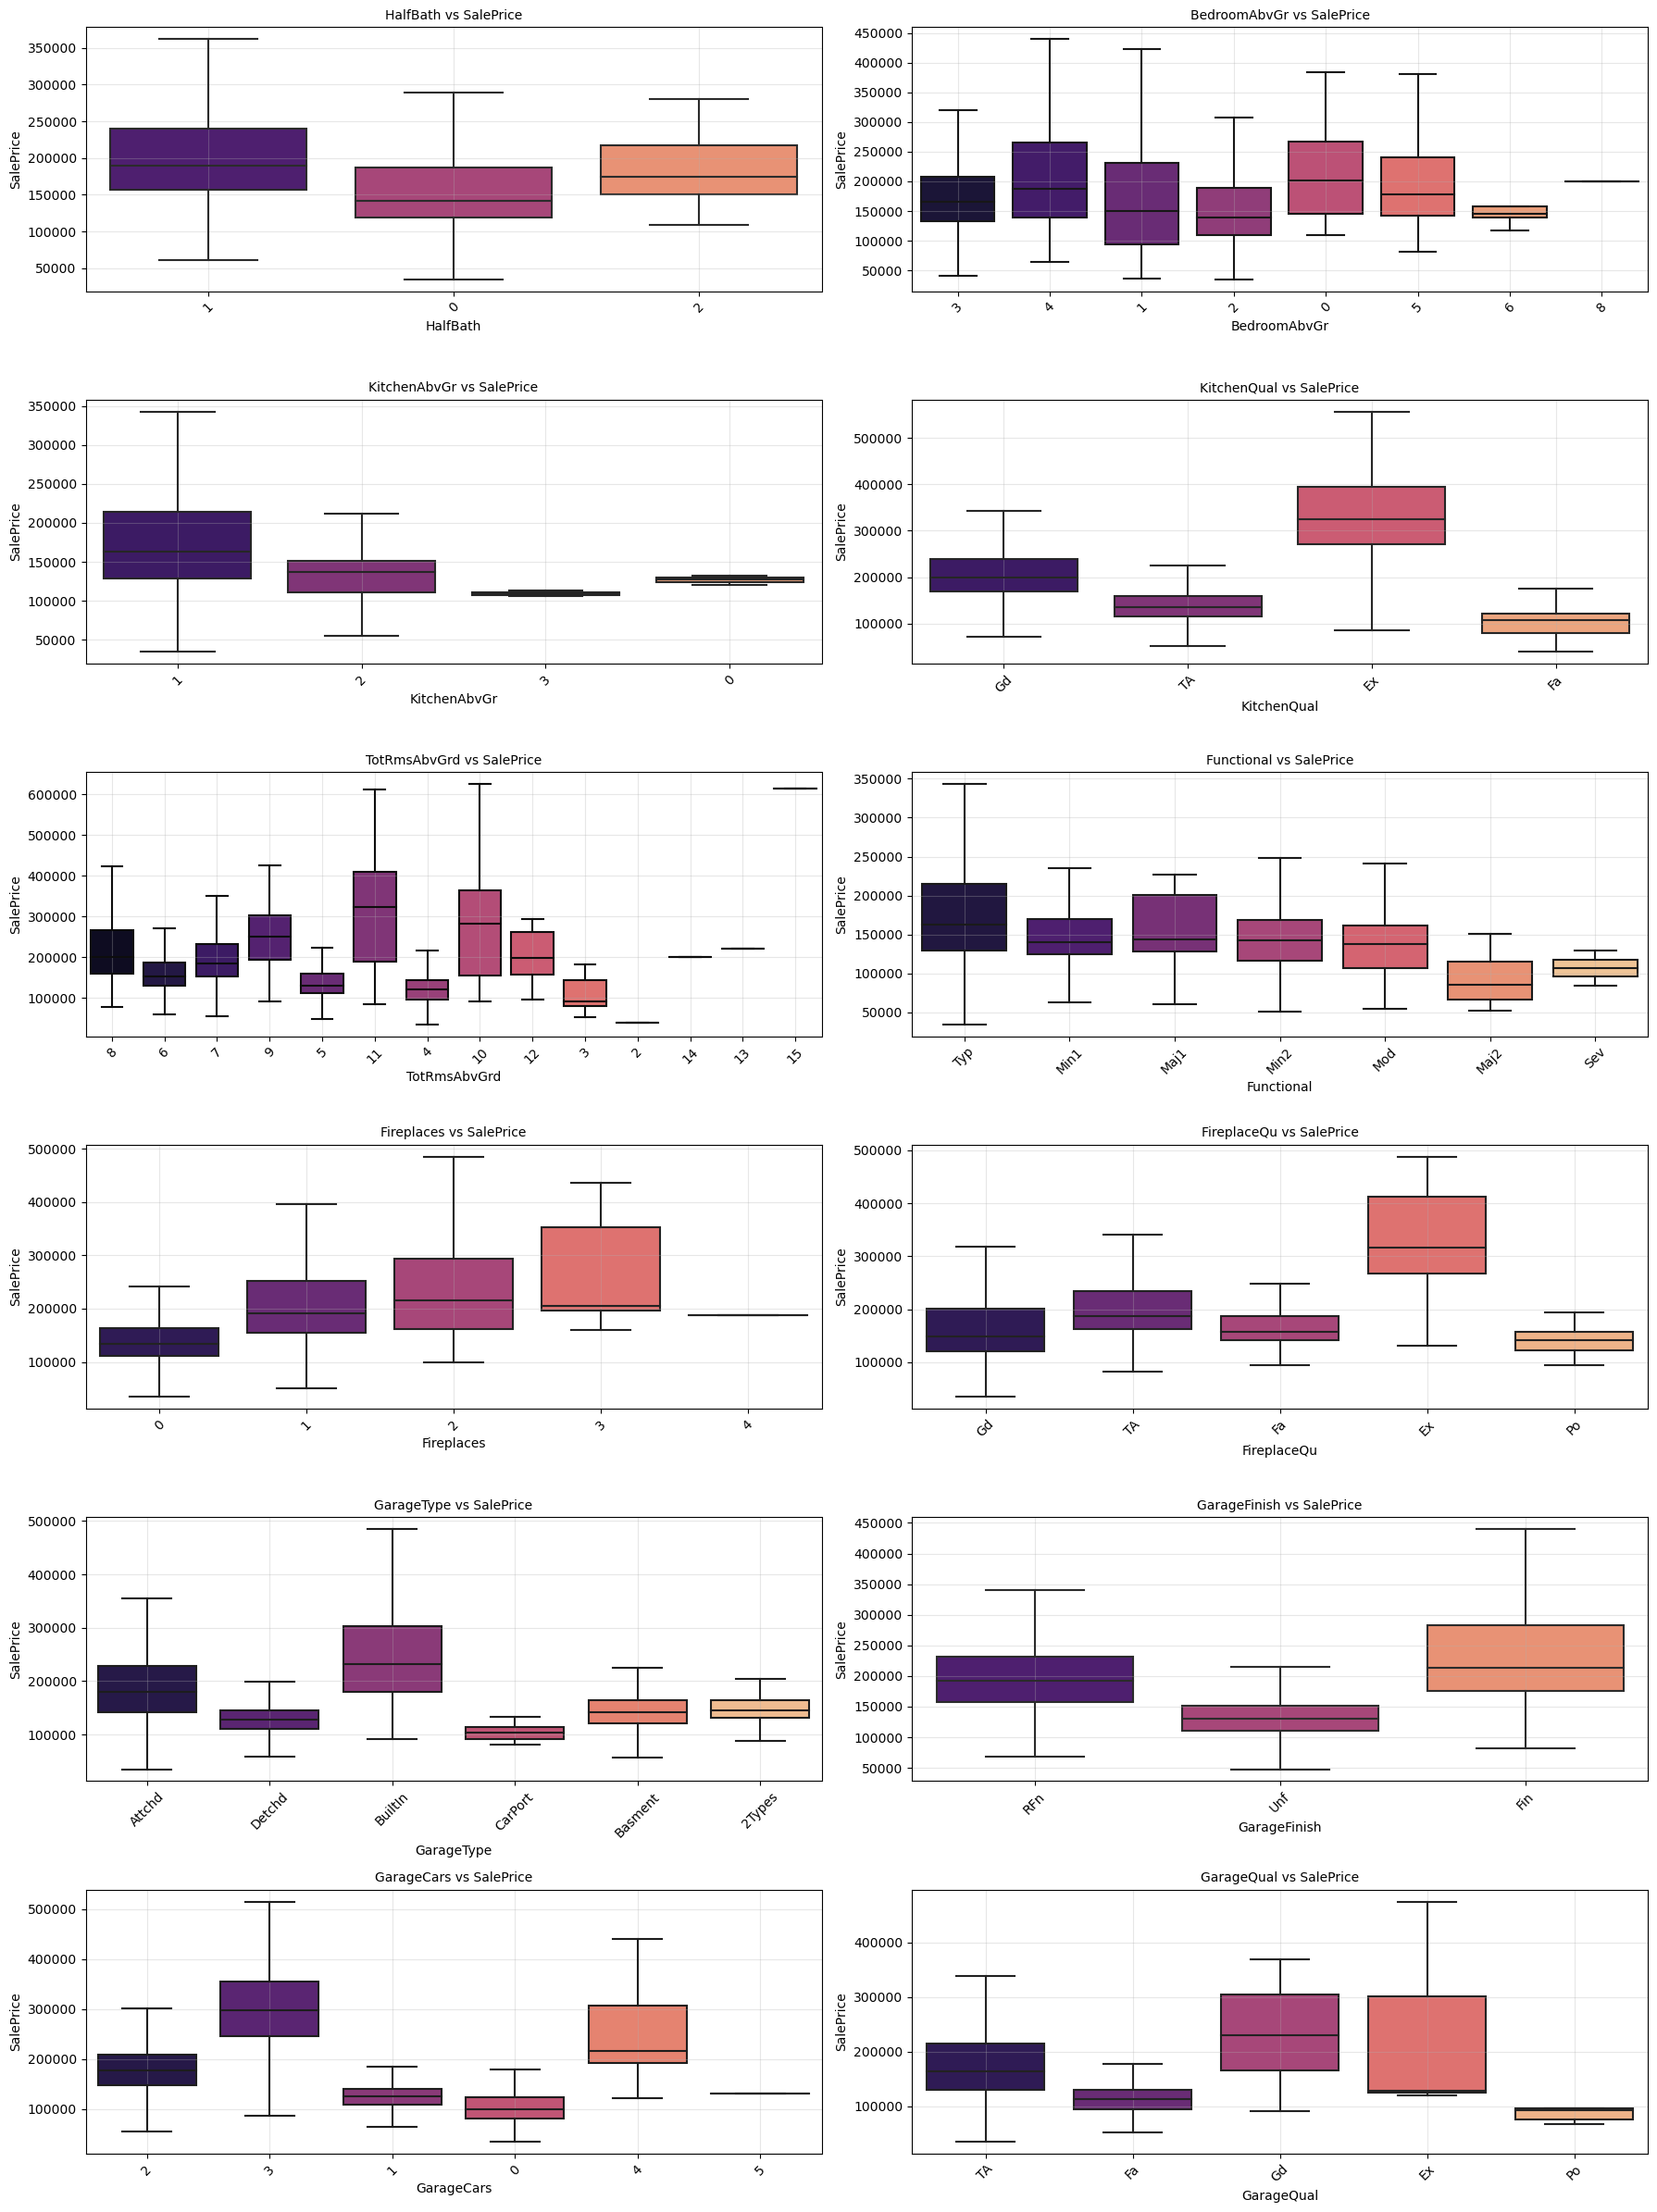

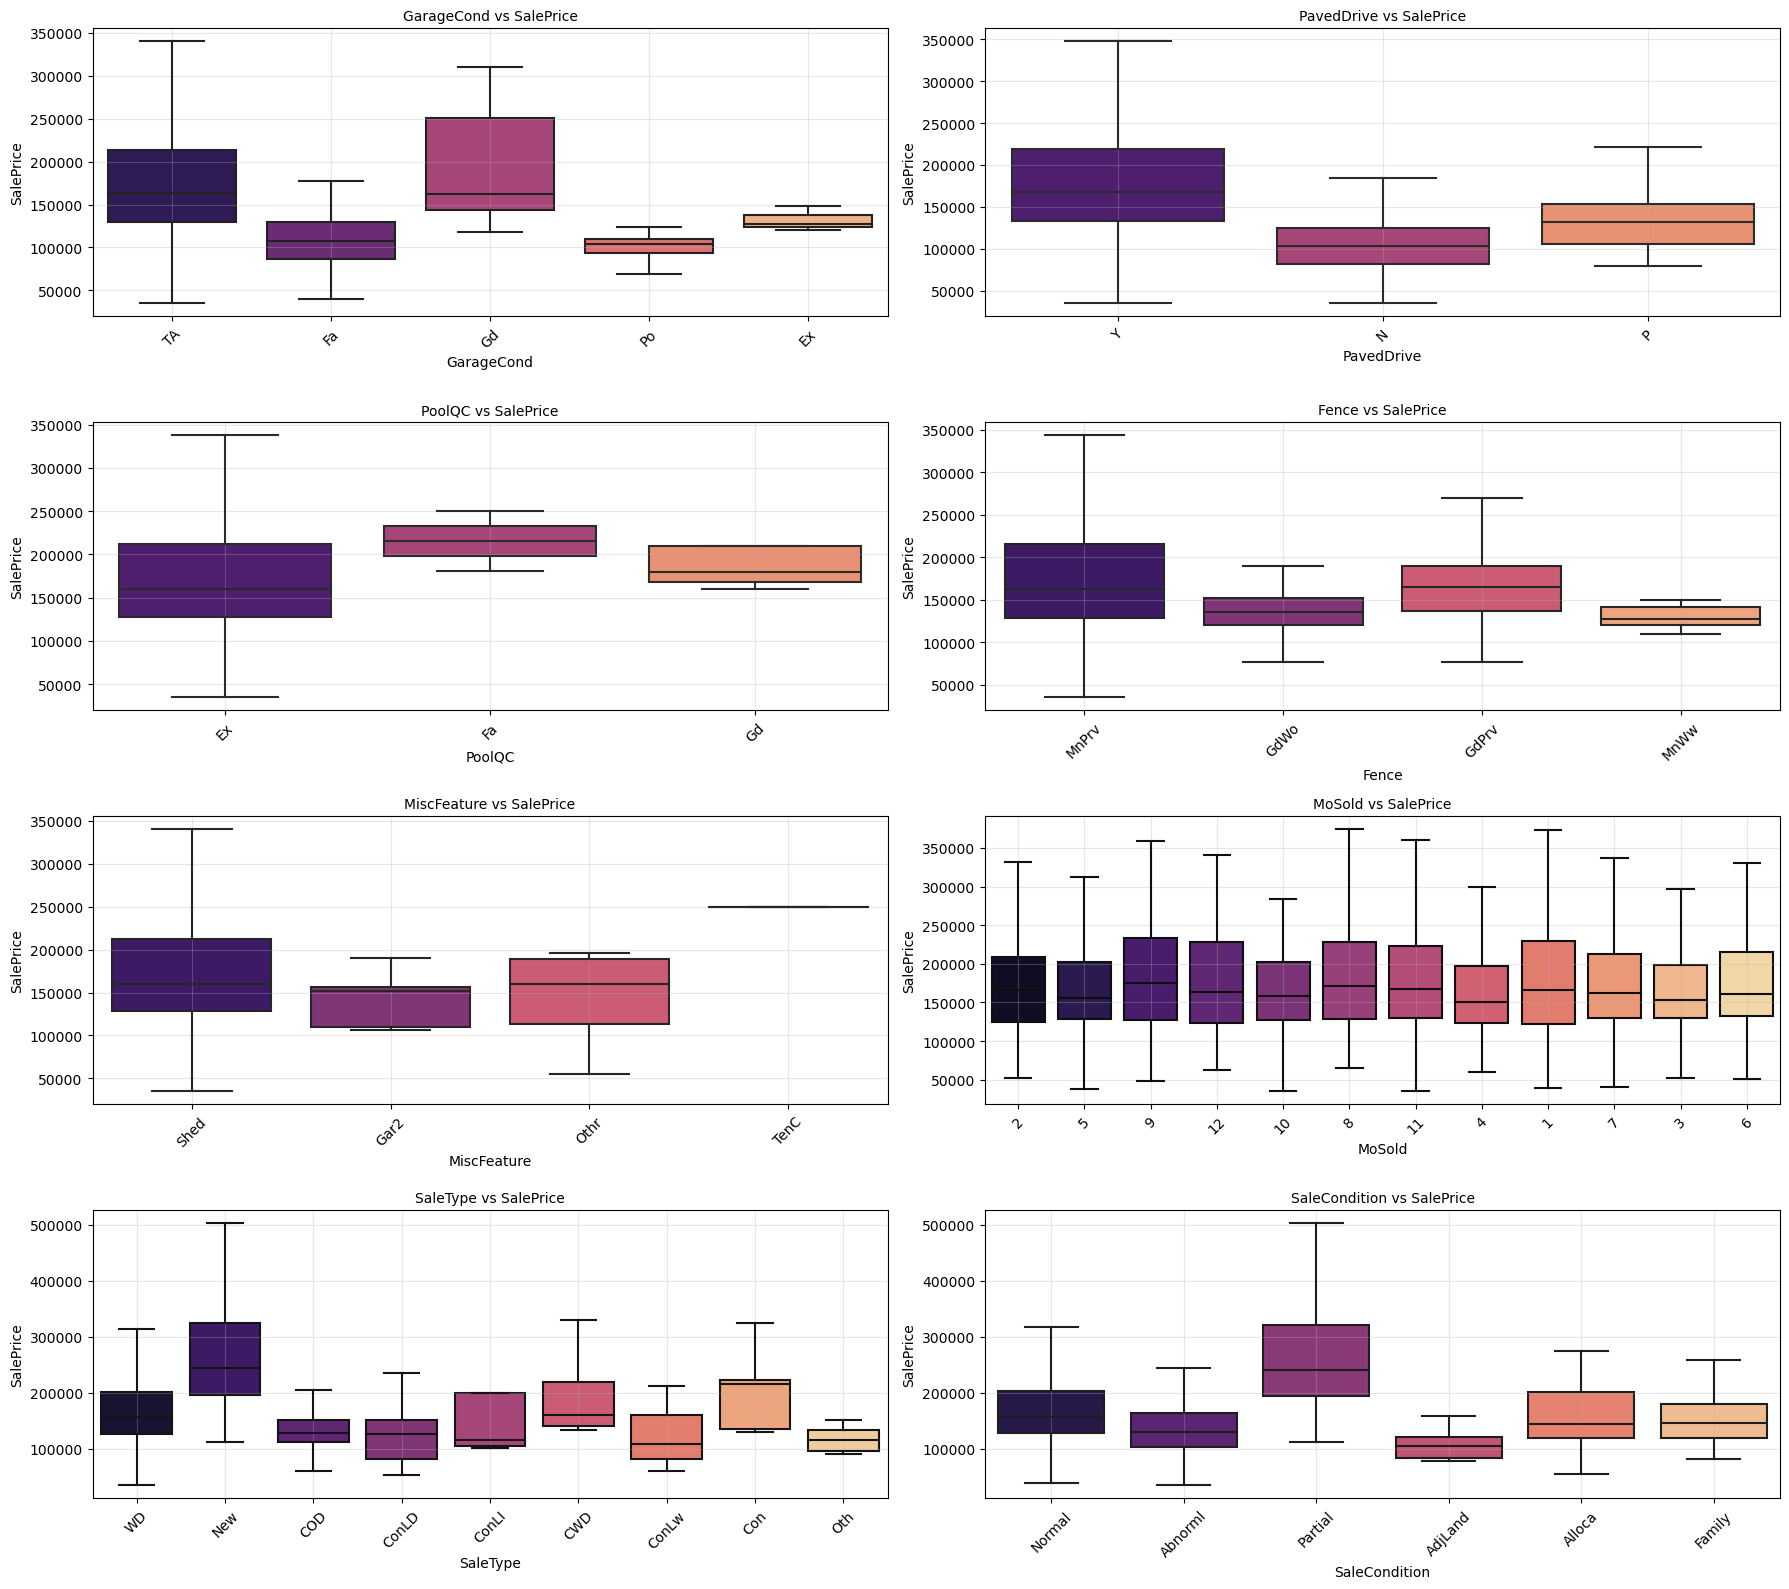

In [31]:

cat_cols = eda_train_ds.select_dtypes(include=["object"]).columns.tolist()

n_cols = 2
plots_per_fig = 12  # 12 plots per figure (6 rows x 2 cols)

for i in range(0, len(cat_cols), plots_per_fig):
    batch = cat_cols[i:i+plots_per_fig]
    n_rows = math.ceil(len(batch) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, batch):
        sns.boxplot(data=eda_ds, x=col, y="SalePrice", ax=ax, showfliers=False, palette="magma")
        ax.set_title(f"{col} vs SalePrice", fontsize=10)
        ax.tick_params(axis="x", rotation=45)
        ax.grid(alpha=0.3)

    # turn off unused axes
    for ax in axes[len(batch):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


The box plots indicated that variables related to material quality, overall condition, number of rooms, number of fireplaces, and garage capacity are strongly associated with 'SalePrice'.

## Feature Selection 

Features chosen by analysis of supposed low correlation in plots: 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'BedroomAbvGr', 'KitchenAbvGr', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'LowQualFinSF', 'Exterior1st', 'Exterior2nd', 'BsmtFullBath', 'BsmtHalfBath','Electrical', 'Functional', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC', 'Fence', 'MiscVal', 'MoSold'. These features were tested by the model to prove their ability to lower the correction of the prediction model.

Feature selection:

In [32]:
low_corr = [
    'Alley',
    'LotShape',
    'LandContour',
    'Utilities',
    'LotConfig',
    'LandSlope',
    'Condition2',
    'BldgType', 
    'HouseStyle', 
    'RoofStyle',
    'BedroomAbvGr',
    'KitchenAbvGr',
    #'BsmtFinType2', 
    #'BsmtFinSF2', 
    #'BsmtUnfSF', 
    #'LowQualFinSF',
    #'BsmtFullBath',
    #'BsmtHalfBath',    
    'Functional', 
    'Exterior1st',
    'Exterior2nd',
    #'WoodDeckSF',
    #'OpenPorchSF',
    #'EnclosedPorch', 
    #'3SsnPorch', 
    #'ScreenPorch', 
    #'PoolArea',
    #'PoolQC',
    'Fence', 
    'MiscVal',
    'MiscFeature',
    'MoSold'
    ]
low_corr

['Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'Functional',
 'Exterior1st',
 'Exterior2nd',
 'Fence',
 'MiscVal',
 'MiscFeature',
 'MoSold']

### Why these features increase or decrease model accuracy?
Feature selection was performed iteratively, removing low-signal variables and validating each change using cross-validation. Features were retained only if their removal improved or maintained generalization performance.
Features such as 'Alley', 'Fence', 'MiscFeature', and 'MiscVal' contain a high proportion of missing values, were found to be weak predictors. Similarly, features including 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', and 'Condition2' seem to be rather irrelevant for prediction. Several structurally relevant variables, such as 'BldgType', 'HouseStyle', 'BedroomAbvGr', 'KitchenAbvGr', 'Utilities', 'Functional', 'Exterior1st', and 'Exterior2nd', also demonstrate limited contribution. Their predictive effect appears to be largely captured by stronger correlated variables such as 'GrLivArea', 'TotRmsAbvGrd', and 'OverallQual'. 'MoSold' shows only a weak seasonal influence on pricing.
In contrast, variables ('BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'LowQualFinSF', 'BsmtFullBath', 'BsmtHalfBath') provide meaningful information about usable living space and structural value. Outdoor and amenity features ('WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'), although sparse, are associated with higher-end properties and contributed positively to predictive performance.

## Ridge Model
I implemented a Ridge regression model using a fully pipeline-based preprocessing workflow, including log transformation of the target, imputation, scaling, one-hot encoding, skew correction, and custom feature engineering.\
Ridge regression is the regular linear regression with a built-in “brake pedal.” 
When a model tries too hard to perfectly fit the training data, it can give some features very large weights. That often leads to overfitting — great performance on training data, worse performance on new data.\
Ridge adds a penalty for large weights. It gently pushes all coefficients to be smaller, making the model more stable and less sensitive to noise.

In [23]:


# ----- Data -----
X = train_ds.drop("SalePrice", axis=1).copy()
y = np.log1p(train_ds["SalePrice"])

# ----- Feature Engineering -----
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # engineered features
        if {"TotalBsmtSF", "1stFlrSF", "2ndFlrSF"}.issubset(X.columns):
            X["TotalSF"] = X["TotalBsmtSF"] + X["1stFlrSF"] + X["2ndFlrSF"]

        if {"YrSold", "YearBuilt"}.issubset(X.columns):
            X["HouseAge"] = X["YrSold"] - X["YearBuilt"]

        if {"YrSold", "YearRemodAdd"}.issubset(X.columns):
            X["RemodAge"] = X["YrSold"] - X["YearRemodAdd"]

        if {"FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath"}.issubset(X.columns):
            X["TotalBathrooms"] = (
                X["FullBath"] + 0.5 * X["HalfBath"]
                + X["BsmtFullBath"] + 0.5 * X["BsmtHalfBath"]
            )

        if "PoolQC" in X.columns:
            X["HasPool"] = X["PoolQC"].notna().astype(int)
        
        if "GarageCars" in X.columns:
            X["HasGarage"] = (pd.to_numeric(X["GarageCars"], errors="coerce").fillna(0) > 0).astype(int)
        elif "GarageArea" in X.columns:
            X["HasGarage"] = (pd.to_numeric(X["GarageArea"], errors="coerce").fillna(0) > 0).astype(int)
        elif "GarageQual" in X.columns:
            X["HasGarage"] = X["GarageQual"].notna().astype(int)            

        return X

class SkewLog1p(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.75, exclude=None):
        self.threshold = threshold
        self.exclude = exclude  # keep as passed (clone-safe)

    def fit(self, X, y=None):
        X = X.copy()
        num_cols = X.select_dtypes(include=["int64", "float64"]).columns
        sk = X[num_cols].skew(numeric_only=True).abs()
        skewed = sk[sk > self.threshold].index.tolist()

        exclude_set = set(self.exclude) if self.exclude is not None else set()
        self.skewed_cols_ = [c for c in skewed if c not in exclude_set]
        return self

    def transform(self, X):
        X = X.copy()
        for c in getattr(self, "skewed_cols_", []):
            if c in X.columns:
                # clip to avoid log1p negatives (e.g. age features in edge cases)
                X[c] = np.log1p(np.clip(X[c], 0, None))
        return X

exclude_yearish = ("YearBuilt", "YearRemodAdd", "GarageYrBlt", "YrSold", "MoSold")

needed_for_fe = {
    "TotalBsmtSF","1stFlrSF","2ndFlrSF",
    "YrSold","YearBuilt","YearRemodAdd",
    "FullBath","HalfBath","BsmtFullBath","BsmtHalfBath",
    "PoolQC","GarageCars","GarageArea","GarageQual",
    "BsmtFinSF2"
}

if "low_corr" in globals():
    low_corr_safe = [c for c in low_corr if c not in needed_for_fe]
    X = X.drop(columns=[c for c in low_corr_safe if c in X.columns])
    test_ds = test_ds.drop(columns=[c for c in low_corr_safe if c in test_ds.columns])

# ----- Split -----
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----- Preprocess -----
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, make_column_selector(dtype_include=np.number)),
    ("cat", categorical_pipeline, make_column_selector(dtype_exclude=np.number)),
])

# ----- Model -----
model = Pipeline([
    ("fe", FeatureEngineer()),
    ("skew", SkewLog1p(threshold=0.75, exclude=exclude_yearish)),
    ("preprocessor", preprocessor),
    ("regressor", Ridge()) 
])


I searched for the best value of alpha (the strength of regularization) using 5-fold cross-validation.\
The data was split into 5 parts, and the model was trained and validated five times, each time using a different fold as validation. 
I tested 40 different alpha values ranging from 0.001 to 100, spaced logarithmically to explore both very small and large regularization strengths.\
The model was evaluated using RMSE, and the alpha that produced the lowest average RMSE across folds was selected.

Values:

In [24]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {"regressor__alpha": np.logspace(-3, 2, 40)}  # 0.001 → 100
grid = GridSearchCV(
    model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)
grid.fit(X, y)

print("Best alpha:", grid.best_params_["regressor__alpha"])
print("Best CV RMSE:", -grid.best_score_)
best_ridge = grid.best_estimator_

Best alpha: 0.001
Best CV RMSE: 0.12746354709463686


Fitting model:

In [25]:
best_ridge.fit(X_train, y_train)

Pipeline(steps=[('fe', FeatureEngineer()),
                ('skew',
                 SkewLog1p(exclude=('YearBuilt', 'YearRemodAdd', 'GarageYrBlt',
                                    'YrSold', 'MoSold'))),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000027F001F8D50>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000027F77B37050>)])),
                ('regressor', Ridge(alpha=0.001))])

The model is evaluated on the validation set using RMSE and R² to measure prediction accuracy and explanatory power.
RMSE measures the average size of prediction errors. R² measures how much of the target variance the model explains.

https://en.wikipedia.org/wiki/Root_mean_square_deviation

https://en.wikipedia.org/wiki/Coefficient_of_determination


RMSE and R²:

In [26]:
y_pred = best_ridge.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print(f"Validation RMSE (log scale): {rmse:.6f}")
print(f"Validation R²: {r2:.6f}")

Validation RMSE (log scale): 0.117803
Validation R²: 0.925634


RMSE ≈ 0.118\
R² ≈ 0.925

This means: 
1.  Errors are relatively small
2.  The model explains most price variation
3.  Strong linear baseline performance

I converted predictions back to real prices and calculated RMSE in dollars:

In [27]:
rmse_dollars = np.sqrt(
    mean_squared_error(np.expm1(y_val), np.expm1(y_pred))
)

Final prediction for test_ds:

In [28]:
test_preds = np.expm1(best_ridge.predict(test_ds))

test_preds[:10]

array([125422.5262022 , 157256.02449643, 185985.52322632, 201042.53838441,
       204879.86873829, 174075.29267014, 184222.20882944, 162441.07234119,
       196948.19904027, 118657.72182559])

Saving prediction into test.csv:

In [29]:
test_final = pd.read_csv("../prices/Datasets/test.csv")  
test_final["SalePrice"] = test_preds

test_final.to_csv("../prices/Datasets/test_with_predictions.csv", index=False)

test_final.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,125422.526202
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,157256.024496
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,185985.523226
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,201042.538384
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,204879.868738


## Final Project Summary:
The goal of this project was to predict house sale prices of the Ames Housing dataset, applying preprocessing, EDA, feature pruning, feature engineering, regularization, and cross-validation to build a stable and interpretable regression model.\
The final model achieves performance close to the practical ceiling for regularized linear models on this dataset. However, the results highlight that careful feature examination, domain understanding, and thoughtful feature selection remain critical for maximizing predictive performance.

---

### End

---
## Data Description
MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM	Residential Medium Density
	
LotFrontage: Linear feet of street connected to property

LotArea: Lot size in square feet

Street: Type of road access to property

       Grvl	Gravel	
       Pave	Paved
       	
Alley: Type of alley access to property

       Grvl	Gravel
       Pave	Paved
       NA 	No alley access
		
LotShape: General shape of property

       Reg	Regular	
       IR1	Slightly irregular
       IR2	Moderately Irregular
       IR3	Irregular
       
LandContour: Flatness of the property

       Lvl	Near Flat/Level	
       Bnk	Banked - Quick and significant rise from street grade to building
       HLS	Hillside - Significant slope from side to side
       Low	Depression
		
Utilities: Type of utilities available
		
       AllPub	All public Utilities (E,G,W,& S)	
       NoSewr	Electricity, Gas, and Water (Septic Tank)
       NoSeWa	Electricity and Gas Only
       ELO	Electricity only	
	
LotConfig: Lot configuration

       Inside	Inside lot
       Corner	Corner lot
       CulDSac	Cul-de-sac
       FR2	Frontage on 2 sides of property
       FR3	Frontage on 3 sides of property
	
LandSlope: Slope of property
		
       Gtl	Gentle slope
       Mod	Moderate Slope	
       Sev	Severe Slope
	
Neighborhood: Physical locations within Ames city limits

       Blmngtn	Bloomington Heights
       Blueste	Bluestem
       BrDale	Briardale
       BrkSide	Brookside
       ClearCr	Clear Creek
       CollgCr	College Creek
       Crawfor	Crawford
       Edwards	Edwards
       Gilbert	Gilbert
       IDOTRR	Iowa DOT and Rail Road
       MeadowV	Meadow Village
       Mitchel	Mitchell
       Names	North Ames
       NoRidge	Northridge
       NPkVill	Northpark Villa
       NridgHt	Northridge Heights
       NWAmes	Northwest Ames
       OldTown	Old Town
       SWISU	South & West of Iowa State University
       Sawyer	Sawyer
       SawyerW	Sawyer West
       Somerst	Somerset
       StoneBr	Stone Brook
       Timber	Timberland
       Veenker	Veenker
			
Condition1: Proximity to various conditions
	
       Artery	Adjacent to arterial street
       Feedr	Adjacent to feeder street	
       Norm	Normal	
       RRNn	Within 200' of North-South Railroad
       RRAn	Adjacent to North-South Railroad
       PosN	Near positive off-site feature--park, greenbelt, etc.
       PosA	Adjacent to postive off-site feature
       RRNe	Within 200' of East-West Railroad
       RRAe	Adjacent to East-West Railroad
	
Condition2: Proximity to various conditions (if more than one is present)
		
       Artery	Adjacent to arterial street
       Feedr	Adjacent to feeder street	
       Norm	Normal	
       RRNn	Within 200' of North-South Railroad
       RRAn	Adjacent to North-South Railroad
       PosN	Near positive off-site feature--park, greenbelt, etc.
       PosA	Adjacent to postive off-site feature
       RRNe	Within 200' of East-West Railroad
       RRAe	Adjacent to East-West Railroad
	
BldgType: Type of dwelling
		
       1Fam	Single-family Detached	
       2FmCon	Two-family Conversion; originally built as one-family dwelling
       Duplx	Duplex
       TwnhsE	Townhouse End Unit
       TwnhsI	Townhouse Inside Unit
	
HouseStyle: Style of dwelling
	
       1Story	One story
       1.5Fin	One and one-half story: 2nd level finished
       1.5Unf	One and one-half story: 2nd level unfinished
       2Story	Two story
       2.5Fin	Two and one-half story: 2nd level finished
       2.5Unf	Two and one-half story: 2nd level unfinished
       SFoyer	Split Foyer
       SLvl	Split Level
	
OverallQual: Rates the overall material and finish of the house

       10	Very Excellent
       9	Excellent
       8	Very Good
       7	Good
       6	Above Average
       5	Average
       4	Below Average
       3	Fair
       2	Poor
       1	Very Poor
	
OverallCond: Rates the overall condition of the house

       10	Very Excellent
       9	Excellent
       8	Very Good
       7	Good
       6	Above Average	
       5	Average
       4	Below Average	
       3	Fair
       2	Poor
       1	Very Poor
		
YearBuilt: Original construction date

YearRemodAdd: Remodel date (same as construction date if no remodeling or additions)

RoofStyle: Type of roof

       Flat	Flat
       Gable	Gable
       Gambrel	Gabrel (Barn)
       Hip	Hip
       Mansard	Mansard
       Shed	Shed
		
RoofMatl: Roof material

       ClyTile	Clay or Tile
       CompShg	Standard (Composite) Shingle
       Membran	Membrane
       Metal	Metal
       Roll	Roll
       Tar&Grv	Gravel & Tar
       WdShake	Wood Shakes
       WdShngl	Wood Shingles
		
Exterior1st: Exterior covering on house

       AsbShng	Asbestos Shingles
       AsphShn	Asphalt Shingles
       BrkComm	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       CemntBd	Cement Board
       HdBoard	Hard Board
       ImStucc	Imitation Stucco
       MetalSd	Metal Siding
       Other	Other
       Plywood	Plywood
       PreCast	PreCast	
       Stone	Stone
       Stucco	Stucco
       VinylSd	Vinyl Siding
       Wd Sdng	Wood Siding
       WdShing	Wood Shingles
	
Exterior2nd: Exterior covering on house (if more than one material)

       AsbShng	Asbestos Shingles
       AsphShn	Asphalt Shingles
       BrkComm	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       CemntBd	Cement Board
       HdBoard	Hard Board
       ImStucc	Imitation Stucco
       MetalSd	Metal Siding
       Other	Other
       Plywood	Plywood
       PreCast	PreCast
       Stone	Stone
       Stucco	Stucco
       VinylSd	Vinyl Siding
       Wd Sdng	Wood Siding
       WdShing	Wood Shingles
	
MasVnrType: Masonry veneer type

       BrkCmn	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       None	None
       Stone	Stone
	
MasVnrArea: Masonry veneer area in square feet

ExterQual: Evaluates the quality of the material on the exterior 
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor
		
ExterCond: Evaluates the present condition of the material on the exterior
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor
		
Foundation: Type of foundation
		
       BrkTil	Brick & Tile
       CBlock	Cinder Block
       PConc	Poured Contrete	
       Slab	Slab
       Stone	Stone
       Wood	Wood
		
BsmtQual: Evaluates the height of the basement

       Ex	Excellent (100+ inches)	
       Gd	Good (90-99 inches)
       TA	Typical (80-89 inches)
       Fa	Fair (70-79 inches)
       Po	Poor (<70 inches
       NA	No Basement
		
BsmtCond: Evaluates the general condition of the basement

       Ex	Excellent
       Gd	Good
       TA	Typical - slight dampness allowed
       Fa	Fair - dampness or some cracking or settling
       Po	Poor - Severe cracking, settling, or wetness
       NA	No Basement
	
BsmtExposure: Refers to walkout or garden level walls

       Gd	Good Exposure
       Av	Average Exposure (split levels or foyers typically score average or above)	
       Mn	Mimimum Exposure
       No	No Exposure
       NA	No Basement
	
BsmtFinType1: Rating of basement finished area

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters	
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement
		
BsmtFinSF1: Type 1 finished square feet

BsmtFinType2: Rating of basement finished area (if multiple types)

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters	
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement

BsmtFinSF2: Type 2 finished square feet

BsmtUnfSF: Unfinished square feet of basement area

TotalBsmtSF: Total square feet of basement area

Heating: Type of heating
		
       Floor	Floor Furnace
       GasA	Gas forced warm air furnace
       GasW	Gas hot water or steam heat
       Grav	Gravity furnace	
       OthW	Hot water or steam heat other than gas
       Wall	Wall furnace
		
HeatingQC: Heating quality and condition

       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor
		
CentralAir: Central air conditioning

       N	No
       Y	Yes
		
Electrical: Electrical system

       SBrkr	Standard Circuit Breakers & Romex
       FuseA	Fuse Box over 60 AMP and all Romex wiring (Average)	
       FuseF	60 AMP Fuse Box and mostly Romex wiring (Fair)
       FuseP	60 AMP Fuse Box and mostly knob & tube wiring (poor)
       Mix	Mixed
		
1stFlrSF: First Floor square feet
 
2ndFlrSF: Second floor square feet

LowQualFinSF: Low quality finished square feet (all floors)

GrLivArea: Above grade (ground) living area square feet

BsmtFullBath: Basement full bathrooms

BsmtHalfBath: Basement half bathrooms

FullBath: Full bathrooms above grade

HalfBath: Half baths above grade

Bedroom: Bedrooms above grade (does NOT include basement bedrooms)

Kitchen: Kitchens above grade

KitchenQual: Kitchen quality

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       	
TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)

Functional: Home functionality (Assume typical unless deductions are warranted)

       Typ	Typical Functionality
       Min1	Minor Deductions 1
       Min2	Minor Deductions 2
       Mod	Moderate Deductions
       Maj1	Major Deductions 1
       Maj2	Major Deductions 2
       Sev	Severely Damaged
       Sal	Salvage only
		
Fireplaces: Number of fireplaces

FireplaceQu: Fireplace quality

       Ex	Excellent - Exceptional Masonry Fireplace
       Gd	Good - Masonry Fireplace in main level
       TA	Average - Prefabricated Fireplace in main living area or Masonry Fireplace in basement
       Fa	Fair - Prefabricated Fireplace in basement
       Po	Poor - Ben Franklin Stove
       NA	No Fireplace
		
GarageType: Garage location
		
       2Types	More than one type of garage
       Attchd	Attached to home
       Basment	Basement Garage
       BuiltIn	Built-In (Garage part of house - typically has room above garage)
       CarPort	Car Port
       Detchd	Detached from home
       NA	No Garage
		
GarageYrBlt: Year garage was built
		
GarageFinish: Interior finish of the garage

       Fin	Finished
       RFn	Rough Finished	
       Unf	Unfinished
       NA	No Garage
		
GarageCars: Size of garage in car capacity

GarageArea: Size of garage in square feet

GarageQual: Garage quality

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       NA	No Garage
		
GarageCond: Garage condition

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       NA	No Garage
		
PavedDrive: Paved driveway

       Y	Paved 
       P	Partial Pavement
       N	Dirt/Gravel
		
WoodDeckSF: Wood deck area in square feet

OpenPorchSF: Open porch area in square feet

EnclosedPorch: Enclosed porch area in square feet

3SsnPorch: Three season porch area in square feet

ScreenPorch: Screen porch area in square feet

PoolArea: Pool area in square feet

PoolQC: Pool quality
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       NA	No Pool
		
Fence: Fence quality
		
       GdPrv	Good Privacy
       MnPrv	Minimum Privacy
       GdWo	Good Wood
       MnWw	Minimum Wood/Wire
       NA	No Fence
	
MiscFeature: Miscellaneous feature not covered in other categories
		
       Elev	Elevator
       Gar2	2nd Garage (if not described in garage section)
       Othr	Other
       Shed	Shed (over 100 SF)
       TenC	Tennis Court
       NA	None
		
MiscVal: $Value of miscellaneous feature

MoSold: Month Sold (MM)

YrSold: Year Sold (YYYY)

SaleType: Type of sale
		
       WD 	Warranty Deed - Conventional
       CWD	Warranty Deed - Cash
       VWD	Warranty Deed - VA Loan
       New	Home just constructed and sold
       COD	Court Officer Deed/Estate
       Con	Contract 15% Down payment regular terms
       ConLw	Contract Low Down payment and low interest
       ConLI	Contract Low Interest
       ConLD	Contract Low Down
       Oth	Other
		
SaleCondition: Condition of sale

       Normal	Normal Sale
       Abnorml	Abnormal Sale -  trade, foreclosure, short sale
       AdjLand	Adjoining Land Purchase
       Alloca	Allocation - two linked properties with separate deeds, typically condo with a garage unit	
       Family	Sale between family members
       Partial	Home was not completed when last assessed (associated with New Homes)
